# Credit Risk Grade Prediction: Multiclass Classification

**Course:** Basics of AI and Machine Learning — Final Project  
**Task:** Tabular Data Classification — Model Comparison and Analysis  
**Dataset:** [Credit Risk Dataset (Kaggle)](https://www.kaggle.com/datasets/laotse/credit-risk-dataset)  
**Target Variable:** `loan_grade` (A, B, C, D, E, F, G) — 7-class classification  

---

## Problem Statement

We predict the **credit risk grade** assigned to a loan applicant based on their demographic profile, financial history, and loan characteristics. Accurate risk grading helps lenders price loans correctly and manage portfolio risk. The target `loan_grade` has seven ordinal categories (A = lowest risk, G = highest risk), making this a multiclass classification problem.

---

## Team Contribution Table

| Member | Sections |
|--------|----------|
| Raivo Strods | All sections (individual project) |

## 1. Setup and Data Loading

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)
from sklearn.preprocessing import label_binarize

sns.set_theme(style='whitegrid', palette='colorblind', font_scale=1.1)
pd.set_option('display.max_columns', 20)

RANDOM_STATE = 42
print('All imports successful.')

All imports successful.


In [2]:
df = pd.read_csv('../data/raw/credit_risk_dataset.csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


## 2. Exploratory Data Analysis (EDA)

In [3]:
print('--- Basic Info ---')
print(f'Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}')
print()
df.info()

--- Basic Info ---
Rows: 32,581  |  Columns: 12

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 

In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
person_age,32581.0,NaN,NaN,NaN,27.7346,6.348078,20.0,23.0,26.0,30.0,144.0
person_income,32581.0,NaN,NaN,NaN,66074.84847,61983.119168,4000.0,38500.0,55000.0,79200.0,6000000.0
person_home_ownership,32581,4,RENT,16446,NaN,NaN,NaN,NaN,NaN,NaN,NaN
person_emp_length,31686.0,NaN,NaN,NaN,4.789686,4.14263,0.0,2.0,4.0,7.0,123.0
loan_intent,32581,6,EDUCATION,6453,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_grade,32581,7,A,10777,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amnt,32581.0,NaN,NaN,NaN,9589.371106,6322.086646,500.0,5000.0,8000.0,12200.0,35000.0
loan_int_rate,29465.0,NaN,NaN,NaN,11.011695,3.240459,5.42,7.9,10.99,13.47,23.22
loan_status,32581.0,NaN,NaN,NaN,0.218164,0.413006,0.0,0.0,0.0,0.0,1.0
loan_percent_income,32581.0,NaN,NaN,NaN,0.170203,0.106782,0.0,0.09,0.15,0.23,0.83


### 2.1 Missing Values

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Count': missing, 'Percent': missing_pct}).query('Count > 0')
print('Missing values:')
print(missing_df)
print()
emp_pct = missing_pct.get('person_emp_length', 0)
rate_pct = missing_pct.get('loan_int_rate', 0)
print('Strategy:')
print(f'- person_emp_length ({emp_pct}% missing): impute with sentinel value -999.')
print('  Rationale: missingness may be informative (unemployed, self-employed).')
print('  Trees can learn to split on -999; median would falsely assume typical employment.')
print(f'- loan_int_rate ({rate_pct}% missing): DROPPED (leakage — interest rate is determined by loan grade).')
print('- loan_status: DROPPED (leakage — default outcome only known after loan lifecycle).')

Missing values:
                   Count  Percent
person_emp_length    895     2.75
loan_int_rate       3116     9.56

Strategy:
- person_emp_length (2.75% missing): impute with sentinel value -999.
  Rationale: missingness may be informative (unemployed, self-employed).
  Trees can learn to split on -999; median would falsely assume typical employment.
- loan_int_rate (9.56% missing): DROPPED (leakage — interest rate is determined by loan grade).
- loan_status: DROPPED (leakage — default outcome only known after loan lifecycle).


### 2.2 Target Distribution

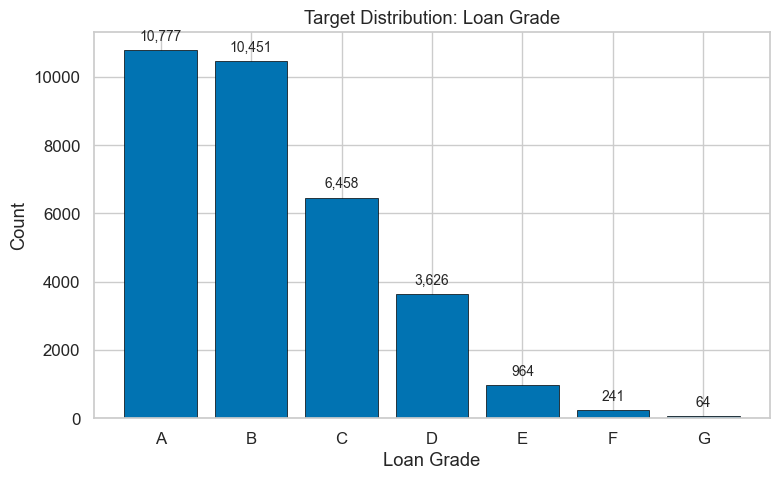


Class proportions:
loan_grade
A    33.1
B    32.1
C    19.8
D    11.1
E     3.0
F     0.7
G     0.2

The dataset is imbalanced: grades A and B dominate (~65%), while E/F/G together are <4%.
We will use class_weight="balanced" where supported and stratified splits to handle this.


In [6]:
grade_order = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
grade_counts = df['loan_grade'].value_counts().reindex(grade_order)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(grade_counts.index, grade_counts.values, edgecolor='black', linewidth=0.5)
for bar, count in zip(bars, grade_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{count:,}', ha='center', va='bottom', fontsize=10)
ax.set_xlabel('Loan Grade')
ax.set_ylabel('Count')
ax.set_title('Target Distribution: Loan Grade')
plt.tight_layout()
plt.show()

print('\nClass proportions:')
print((grade_counts / len(df) * 100).round(1).to_string())
print('\nThe dataset is imbalanced: grades A and B dominate (~65%), while E/F/G together are <4%.')
print('We will use class_weight="balanced" where supported and stratified splits to handle this.')

### 2.3 Numerical Feature Distributions (by target)

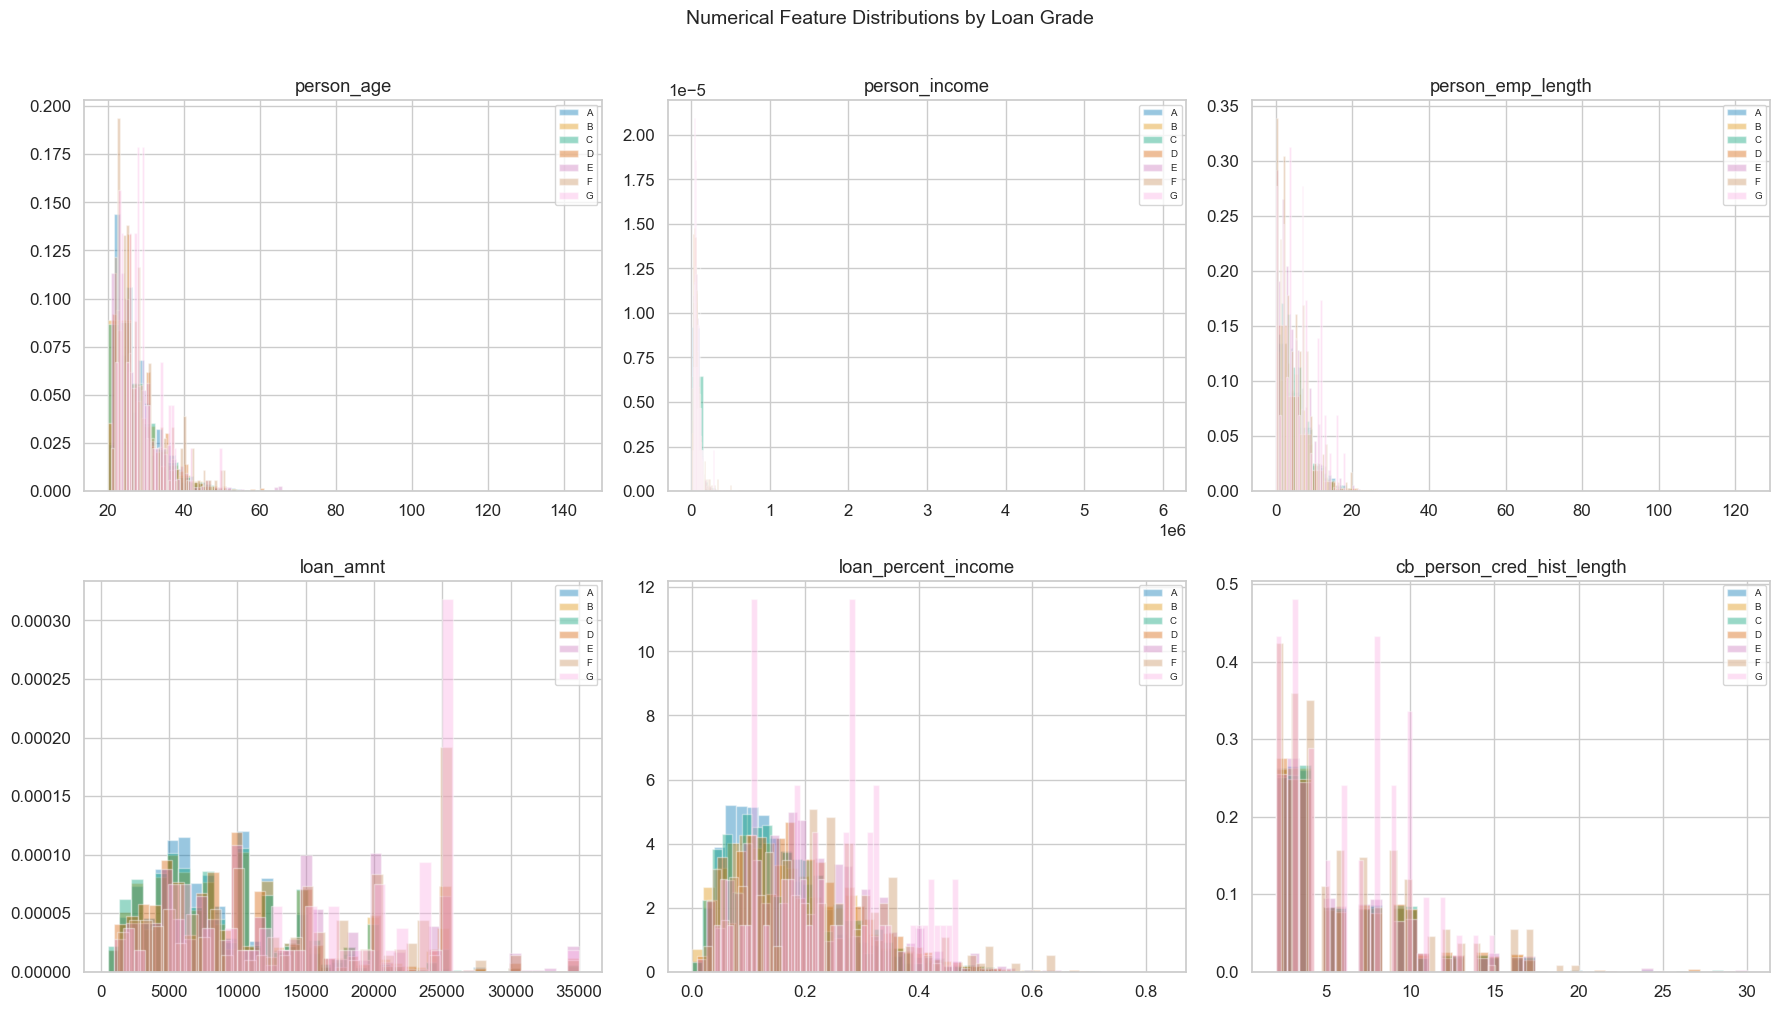

In [7]:
num_features = ['person_age', 'person_income', 'person_emp_length',
                'loan_amnt', 'loan_percent_income', 'cb_person_cred_hist_length']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, col in zip(axes.ravel(), num_features):
    for grade in grade_order:
        subset = df[df['loan_grade'] == grade][col].dropna()
        ax.hist(subset, bins=40, alpha=0.4, label=grade, density=True)
    ax.set_title(col)
    ax.legend(fontsize=7, loc='upper right')
fig.suptitle('Numerical Feature Distributions by Loan Grade', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 2.4 Correlation Heatmap

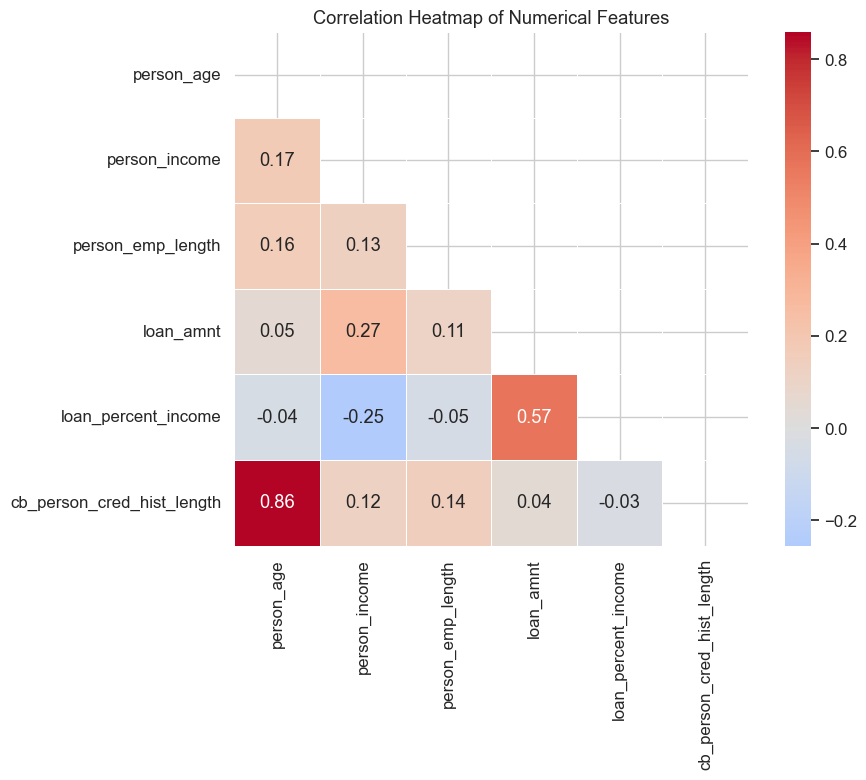

In [8]:
num_cols_for_corr = ['person_age', 'person_income', 'person_emp_length',
                     'loan_amnt', 'loan_percent_income', 'cb_person_cred_hist_length']

fig, ax = plt.subplots(figsize=(10, 8))
corr = df[num_cols_for_corr].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

### 2.5 Categorical Feature Distributions

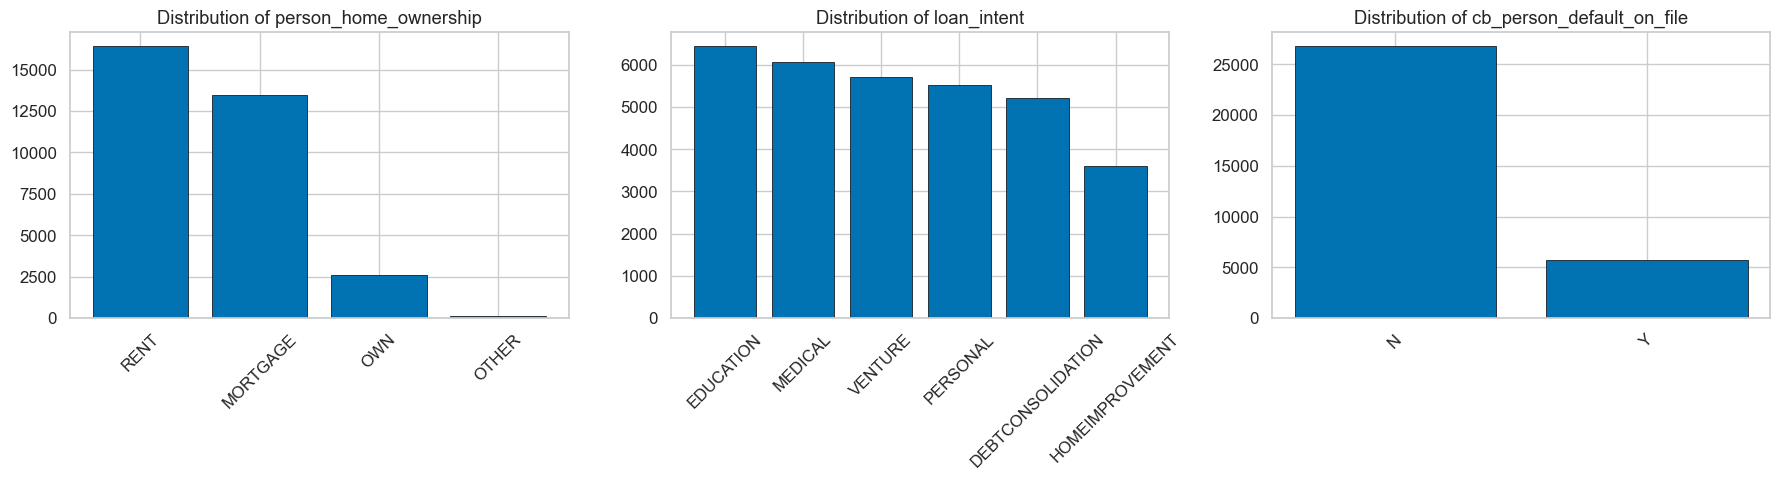

In [9]:
cat_features = ['person_home_ownership', 'loan_intent', 'cb_person_default_on_file']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, cat_features):
    counts = df[col].value_counts()
    ax.bar(counts.index, counts.values, edgecolor='black', linewidth=0.5)
    ax.set_title(f'Distribution of {col}')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### 2.6 Box Plots — Spread and Outliers

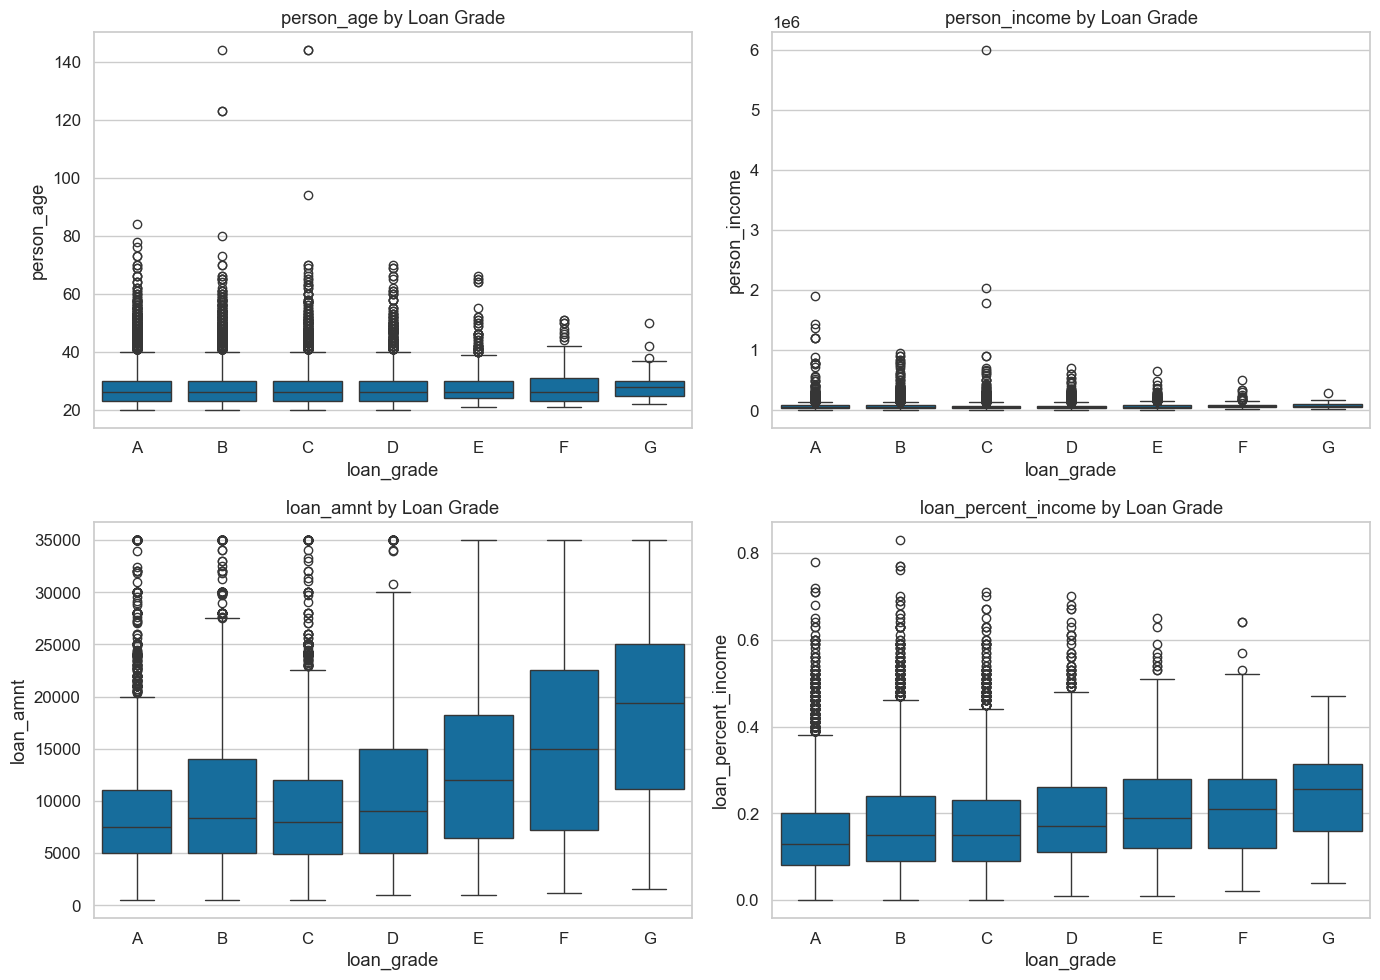

Observations:
- person_age has extreme outliers (>100); likely data errors — will cap at 100.
- person_income has extreme right-tail outliers.
- loan_percent_income and loan_amnt increase with worse grades (D-G), as expected.


In [10]:
box_features = ['person_age', 'person_income', 'loan_amnt', 'loan_percent_income']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.ravel(), box_features):
    sns.boxplot(data=df, x='loan_grade', y=col, order=grade_order, ax=ax)
    ax.set_title(f'{col} by Loan Grade')
plt.tight_layout()
plt.show()

print('Observations:')
print('- person_age has extreme outliers (>100); likely data errors — will cap at 100.')
print('- person_income has extreme right-tail outliers.')
print('- loan_percent_income and loan_amnt increase with worse grades (D-G), as expected.')

## 3. Temporal Leakage Analysis

Before preprocessing, we must determine **which features are realistically available at the moment the lender assigns a credit grade**. Features that are determined *by* the grade or only known *after* loan issuance constitute **data leakage** and must be excluded.

### Feature Availability Timeline

| Tier | Feature | Available Before Grading? | Rationale |
|------|---------|--------------------------|-----------|
| **1 — Person Info** | `person_age` | Yes | Demographic, known at application |
| **1 — Person Info** | `person_income` | Yes | Verified during application |
| **1 — Person Info** | `person_emp_length` | Yes | Employment history |
| **1 — Person Info** | `person_home_ownership` | Yes (self-reported) | May be inaccurate but not leakage |
| **2 — Credit Bureau** | `cb_person_default_on_file` | Yes, but unreliable | From a *single* credit bureau — may differ across bureaus |
| **2 — Credit Bureau** | `cb_person_cred_hist_length` | Yes, but unreliable | Bureau-specific; history length varies by bureau |
| **3 — Loan Application** | `loan_intent` | Debatable | Client states purpose when applying |
| **3 — Loan Application** | `loan_amnt` | Debatable | Client requests amount; may change after grading |
| **3 — Loan Application** | `loan_percent_income` | Debatable | Derived from loan_amnt / income; circular if amount changes |
| **4 — LEAKAGE** | `loan_int_rate` | **No** | Interest rate is *determined by* the grade |
| **4 — LEAKAGE** | `loan_status` | **No** | Default outcome only known after loan lifecycle ends |

### Decisions

- **Drop `loan_int_rate`** (already done in current version) — direct function of the target.
- **Drop `loan_status`** — default/non-default is an *outcome*, not a predictor. Including it inflates model scores artificially.
- **Keep Tier 3 features** in the primary experiment (Scenario A), but test without them (Scenario B) to quantify their contribution.
- **Keep Tier 2 features** but treat with caution — single-bureau data may not reflect the full credit picture. Test without them (Scenario C).

### Credit Bureau Caveat

The `cb_person_*` features come from *one* credit bureau out of potentially many (e.g., Experian, Equifax, TransUnion). A person might show "N" for default at one bureau but "Y" at another, or have different credit history lengths depending on which accounts were reported where. A model trained on single-bureau data may not generalize when a different bureau is queried. We quantify this risk via the Scenario B vs C comparison.

## 4. Data Preprocessing and Feature Engineering

In [11]:
df_clean = df.copy()

# Drop Tier-4 leakage features (see temporal leakage analysis above)
df_clean = df_clean.drop(columns=['loan_int_rate', 'loan_status'])

# Cap unrealistic person_age values at 100
df_clean['person_age'] = df_clean['person_age'].clip(upper=100)

# Cap person_emp_length at 60 (unrealistic values above that)
df_clean['person_emp_length'] = df_clean['person_emp_length'].clip(upper=60)

print(f'Shape after dropping leakage features (loan_int_rate, loan_status): {df_clean.shape}')
print(f'Features (excluding target): {df_clean.shape[1] - 1}')
print(f'Dropped: loan_int_rate (set by grade), loan_status (outcome after repayment)')

Shape after dropping leakage features (loan_int_rate, loan_status): (32581, 10)
Features (excluding target): 9
Dropped: loan_int_rate (set by grade), loan_status (outcome after repayment)


In [12]:
# Separate target and features
TARGET = 'loan_grade'

y_raw = df_clean[TARGET]
X = df_clean.drop(columns=[TARGET])

# Encode target: A=0, B=1, ..., G=6
le = LabelEncoder()
le.fit(grade_order)
y = le.transform(y_raw)

print('Feature columns:', list(X.columns))
print('Target classes:', le.classes_)
print(f'X shape: {X.shape}  |  y shape: {y.shape}')

Feature columns: ['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_amnt', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']
Target classes: ['A' 'B' 'C' 'D' 'E' 'F' 'G']
X shape: (32581, 9)  |  y shape: (32581,)


### 4.1 Preprocessing Pipeline

We build a `ColumnTransformer` that:
- **Numerical features**: impute missing values with a sentinel value (-999) to preserve the missingness signal, then standardise (for models that benefit from scaling).
- **Categorical features**: impute missing values with the most frequent category, then apply one-hot encoding.

Scaling helps `LogisticRegression` and `KNeighborsClassifier`; tree-based models are invariant to monotone feature transformations, but including scaling in the pipeline does not harm them.

In [13]:
numerical_features = ['person_age', 'person_income', 'person_emp_length',
                      'loan_amnt', 'loan_percent_income',
                      'cb_person_cred_hist_length']

categorical_features = ['person_home_ownership', 'loan_intent', 'cb_person_default_on_file']

# Sentinel imputation: use -999 instead of median so tree-based models can learn
# that "missing" is a distinct category (e.g. unemployed, self-employed).
# Median imputation would falsely tell the model these people have typical values.
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value=-999)),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numerical_pipeline, numerical_features),
    ('cat', categorical_pipeline, categorical_features)
])

print('Preprocessing pipeline defined.')
print(f'  Numerical ({len(numerical_features)}): {numerical_features}')
print(f'  Categorical ({len(categorical_features)}): {categorical_features}')
print(f'  Missing value strategy: sentinel (-999) — preserves missingness signal for trees')

Preprocessing pipeline defined.
  Numerical (6): ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_percent_income', 'cb_person_cred_hist_length']
  Categorical (3): ['person_home_ownership', 'loan_intent', 'cb_person_default_on_file']
  Missing value strategy: sentinel (-999) — preserves missingness signal for trees


## 5. Train–Test Split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f'Training set: {X_train.shape[0]:,} samples')
print(f'Test set:     {X_test.shape[0]:,} samples')
print()
print('Class proportions in train vs test (should be similar):')
train_props = pd.Series(y_train).value_counts(normalize=True).sort_index()
test_props = pd.Series(y_test).value_counts(normalize=True).sort_index()
props_df = pd.DataFrame({'Train %': (train_props*100).round(1), 'Test %': (test_props*100).round(1)},
                        index=le.classes_)
print(props_df)

Training set: 26,064 samples
Test set:     6,517 samples

Class proportions in train vs test (should be similar):
   Train %  Test %
A      NaN     NaN
B      NaN     NaN
C      NaN     NaN
D      NaN     NaN
E      NaN     NaN
F      NaN     NaN
G      NaN     NaN


## 6. Scenario A — Model Training and Hyperparameter Tuning (Full Application Features)

All models below are trained on the **Scenario A** feature set: all Tier 1 + 2 + 3 features (everything except confirmed leakage columns `loan_int_rate` and `loan_status`).

We train five models. For each, a `Pipeline` combines the shared `preprocessor` with the classifier. Hyperparameter tuning uses cross-validation on the **training set only** — the test set remains untouched.

| # | Model | Tuning Method | Rationale |
|---|-------|---------------|----------|
| 1 | Logistic Regression | GridSearchCV | Small parameter space |
| 2 | Decision Tree | RandomizedSearchCV | Larger space, diminishing returns |
| 3 | Random Forest | RandomizedSearchCV | Large combinatorial space |
| 4 | XGBoost | RandomizedSearchCV | Many interacting hyperparameters |
| 5 | K-Nearest Neighbours | GridSearchCV | Small grid, fast to evaluate |

In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

results = {}
best_models = {}

### 6.1 Logistic Regression

In [16]:
pipe_lr = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(max_iter=2000, class_weight='balanced',
                               random_state=RANDOM_STATE))
])

param_grid_lr = {
    'clf__C': [0.001, 0.01, 0.1, 1, 10],
    'clf__penalty': ['l1', 'l2'],
    'clf__solver': ['saga']
}

gs_lr = GridSearchCV(pipe_lr, param_grid_lr, cv=cv, scoring='f1_weighted',
                     n_jobs=-1, verbose=0)
gs_lr.fit(X_train, y_train)

best_models['Logistic Regression'] = gs_lr.best_estimator_
print(f'Best params: {gs_lr.best_params_}')
print(f'Best CV weighted F1: {gs_lr.best_score_:.4f}')

Best params: {'clf__C': 0.1, 'clf__penalty': 'l2', 'clf__solver': 'saga'}
Best CV weighted F1: 0.4075


### 6.2 Decision Tree

In [17]:
pipe_dt = Pipeline([
    ('prep', preprocessor),
    ('clf', DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE))
])

param_dist_dt = {
    'clf__max_depth': [5, 10, 15, 20, 30, None],
    'clf__min_samples_split': [2, 5, 10, 20],
    'clf__min_samples_leaf': [1, 2, 5, 10],
    'clf__criterion': ['gini', 'entropy'],
    'clf__max_leaf_nodes': [50, 100, 200, None]
}

rs_dt = RandomizedSearchCV(pipe_dt, param_dist_dt, n_iter=50, cv=cv,
                           scoring='f1_weighted', n_jobs=-1,
                           random_state=RANDOM_STATE, verbose=0)
rs_dt.fit(X_train, y_train)

best_models['Decision Tree'] = rs_dt.best_estimator_
print(f'Best params: {rs_dt.best_params_}')
print(f'Best CV weighted F1: {rs_dt.best_score_:.4f}')

Best params: {'clf__min_samples_split': 5, 'clf__min_samples_leaf': 1, 'clf__max_leaf_nodes': 100, 'clf__max_depth': 20, 'clf__criterion': 'gini'}
Best CV weighted F1: 0.4000


### 6.3 Random Forest

In [18]:
pipe_rf = Pipeline([
    ('prep', preprocessor),
    ('clf', RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE))
])

param_dist_rf = {
    'clf__n_estimators': [100, 200, 300, 500],
    'clf__max_depth': [10, 15, 20, 30, None],
    'clf__max_features': ['sqrt', 'log2', 0.3, 0.5],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 2, 4],
    'clf__class_weight': ['balanced', 'balanced_subsample']
}

rs_rf = RandomizedSearchCV(pipe_rf, param_dist_rf, n_iter=50, cv=cv,
                           scoring='f1_weighted', n_jobs=-1,
                           random_state=RANDOM_STATE, verbose=0)
rs_rf.fit(X_train, y_train)

best_models['Random Forest'] = rs_rf.best_estimator_
print(f'Best params: {rs_rf.best_params_}')
print(f'Best CV weighted F1: {rs_rf.best_score_:.4f}')

Best params: {'clf__n_estimators': 500, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 1, 'clf__max_features': 0.5, 'clf__max_depth': 15, 'clf__class_weight': 'balanced_subsample'}
Best CV weighted F1: 0.4725


### 6.4 XGBoost

In [19]:
pipe_xgb = Pipeline([
    ('prep', preprocessor),
    ('clf', XGBClassifier(objective='multi:softprob', num_class=7,
                          eval_metric='mlogloss',
                          random_state=RANDOM_STATE, verbosity=0))
])

param_dist_xgb = {
    'clf__n_estimators': [100, 200, 300, 500],
    'clf__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'clf__max_depth': [3, 5, 7, 10],
    'clf__subsample': [0.7, 0.8, 0.9, 1.0],
    'clf__colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'clf__min_child_weight': [1, 3, 5],
    'clf__reg_alpha': [0, 0.1, 1],
    'clf__reg_lambda': [1, 5, 10],
    'clf__gamma': [0, 0.1, 0.5]
}

rs_xgb = RandomizedSearchCV(pipe_xgb, param_dist_xgb, n_iter=60, cv=cv,
                            scoring='f1_weighted', n_jobs=-1,
                            random_state=RANDOM_STATE, verbose=0)
rs_xgb.fit(X_train, y_train)

best_models['XGBoost'] = rs_xgb.best_estimator_
print(f'Best params: {rs_xgb.best_params_}')
print(f'Best CV weighted F1: {rs_xgb.best_score_:.4f}')

Best params: {'clf__subsample': 0.9, 'clf__reg_lambda': 1, 'clf__reg_alpha': 1, 'clf__n_estimators': 100, 'clf__min_child_weight': 3, 'clf__max_depth': 10, 'clf__learning_rate': 0.1, 'clf__gamma': 0, 'clf__colsample_bytree': 0.8}
Best CV weighted F1: 0.4713


### 6.5 K-Nearest Neighbours (Bonus Model)

In [20]:
pipe_knn = Pipeline([
    ('prep', preprocessor),
    ('clf', KNeighborsClassifier())
])

param_grid_knn = {
    'clf__n_neighbors': [3, 5, 7, 11, 15, 21],
    'clf__weights': ['uniform', 'distance'],
    'clf__metric': ['euclidean', 'manhattan']
}

gs_knn = GridSearchCV(pipe_knn, param_grid_knn, cv=cv, scoring='f1_weighted',
                      n_jobs=-1, verbose=0)
gs_knn.fit(X_train, y_train)

best_models['KNN'] = gs_knn.best_estimator_
print(f'Best params: {gs_knn.best_params_}')
print(f'Best CV weighted F1: {gs_knn.best_score_:.4f}')

Best params: {'clf__metric': 'manhattan', 'clf__n_neighbors': 21, 'clf__weights': 'distance'}
Best CV weighted F1: 0.4418


### 6.6 Best Hyperparameters Summary

In [21]:
hp_summary = {
    'Logistic Regression': gs_lr.best_params_,
    'Decision Tree': rs_dt.best_params_,
    'Random Forest': rs_rf.best_params_,
    'XGBoost': rs_xgb.best_params_,
    'KNN': gs_knn.best_params_
}

for name, params in hp_summary.items():
    print(f'\n--- {name} ---')
    for k, v in params.items():
        print(f'  {k.replace("clf__", "")}: {v}')


--- Logistic Regression ---
  C: 0.1
  penalty: l2
  solver: saga

--- Decision Tree ---
  min_samples_split: 5
  min_samples_leaf: 1
  max_leaf_nodes: 100
  max_depth: 20
  criterion: gini

--- Random Forest ---
  n_estimators: 500
  min_samples_split: 5
  min_samples_leaf: 1
  max_features: 0.5
  max_depth: 15
  class_weight: balanced_subsample

--- XGBoost ---
  subsample: 0.9
  reg_lambda: 1
  reg_alpha: 1
  n_estimators: 100
  min_child_weight: 3
  max_depth: 10
  learning_rate: 0.1
  gamma: 0
  colsample_bytree: 0.8

--- KNN ---
  metric: manhattan
  n_neighbors: 21
  weights: distance


### 6.7 Cross-Validation Diagnostics

Per-fold scores reveal model stability. High standard deviation across folds suggests overfitting or sensitivity to the data split.

=== Cross-Validation Diagnostics ===

Model                     CV Mean F1   CV Std    Test F1      Gap
-----------------------------------------------------------------
Logistic Regression           0.4075   0.0072     0.4144  +0.0069
Decision Tree                 0.4000   0.0147     0.4070  +0.0069
Random Forest                 0.4725   0.0056     0.4799  +0.0074
XGBoost                       0.4713   0.0067     0.4657  -0.0056
KNN                           0.4418   0.0074     0.4412  -0.0007


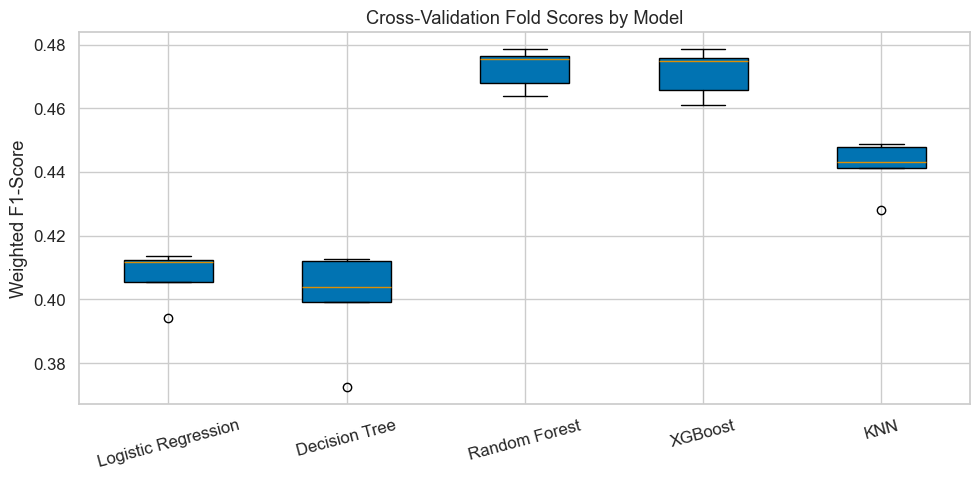


Interpretation:
- Small CV Std = stable model across folds.
- Positive Gap = test score > CV mean (lucky test split or slight underfitting).
- Negative Gap = test score < CV mean (possible overfitting).


In [22]:
from sklearn.model_selection import cross_val_score

cv_diag = {}
for name, model in best_models.items():
    fold_scores = cross_val_score(model, X_train, y_train, cv=cv,
                                  scoring='f1_weighted', n_jobs=-1)
    test_f1 = f1_score(y_test, model.predict(X_test), average='weighted', zero_division=0)
    cv_diag[name] = {
        'fold_scores': fold_scores,
        'cv_mean': fold_scores.mean(),
        'cv_std': fold_scores.std(),
        'test_f1': test_f1,
        'gap': test_f1 - fold_scores.mean()
    }

print('=== Cross-Validation Diagnostics ===\n')
print(f'{"Model":<25s} {"CV Mean F1":>10s} {"CV Std":>8s} {"Test F1":>10s} {"Gap":>8s}')
print('-' * 65)
for name, d in cv_diag.items():
    print(f'{name:<25s} {d["cv_mean"]:>10.4f} {d["cv_std"]:>8.4f} {d["test_f1"]:>10.4f} {d["gap"]:>+8.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
fold_data = [cv_diag[n]['fold_scores'] for n in cv_diag]
bp = ax.boxplot(fold_data, labels=list(cv_diag.keys()), patch_artist=True)
ax.set_ylabel('Weighted F1-Score')
ax.set_title('Cross-Validation Fold Scores by Model')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

print('\nInterpretation:')
print('- Small CV Std = stable model across folds.')
print('- Positive Gap = test score > CV mean (lucky test split or slight underfitting).')
print('- Negative Gap = test score < CV mean (possible overfitting).')

## 7. Feature-Tier Experiments (Scenarios B & C)

We test how model performance changes as we restrict the feature set to only features available at earlier stages of the lending process:

- **Scenario A** (already trained above): All Tier 1 + 2 + 3 features — full application data
- **Scenario B**: Tier 1 + 2 only (person info + credit bureau) — "Can we grade before the client specifies a loan?"
- **Scenario C**: Tier 1 only (person demographics) — "Can we grade without any credit bureau data?"

We use XGBoost for this comparison as the representative tree-based model, keeping the experiment consistent across all three scenarios with the same algorithm and hyperparameter search space.

In [23]:
scenario_features = {
    'B': {
        'num': ['person_age', 'person_income', 'person_emp_length',
                'cb_person_cred_hist_length'],
        'cat': ['person_home_ownership', 'cb_person_default_on_file'],
        'desc': 'Tier 1+2: Person info + credit bureau (no loan details)'
    },
    'C': {
        'num': ['person_age', 'person_income', 'person_emp_length'],
        'cat': ['person_home_ownership'],
        'desc': 'Tier 1 only: Person demographics (no credit bureau, no loan details)'
    }
}

scenario_results = {}

# Scenario A result (from main training)
y_pred_a = best_models['XGBoost'].predict(X_test)
y_proba_a = best_models['XGBoost'].predict_proba(X_test)
scenario_results['A'] = {
    'f1': f1_score(y_test, y_pred_a, average='weighted', zero_division=0),
    'acc': accuracy_score(y_test, y_pred_a),
    'roc': roc_auc_score(label_binarize(y_test, classes=list(range(7))),
                         y_proba_a, average='weighted', multi_class='ovr'),
    'desc': 'Tier 1+2+3: Full application features'
}

for scenario_name, cfg in scenario_features.items():
    num_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value=-999)),
        ('scaler', StandardScaler())
    ])
    cat_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    prep = ColumnTransformer([
        ('num', num_pipe, cfg['num']),
        ('cat', cat_pipe, cfg['cat'])
    ])

    pipe = Pipeline([
        ('prep', prep),
        ('clf', XGBClassifier(objective='multi:softprob', num_class=7,
                              eval_metric='mlogloss',
                              random_state=RANDOM_STATE, verbosity=0))
    ])

    param_dist = {
        'clf__n_estimators': [100, 200, 300, 500],
        'clf__learning_rate': [0.01, 0.05, 0.1, 0.2],
        'clf__max_depth': [3, 5, 7, 10],
        'clf__subsample': [0.7, 0.8, 0.9, 1.0],
        'clf__colsample_bytree': [0.7, 0.8, 0.9, 1.0],
        'clf__min_child_weight': [1, 3, 5],
        'clf__reg_alpha': [0, 0.1, 1],
        'clf__reg_lambda': [1, 5, 10],
        'clf__gamma': [0, 0.1, 0.5]
    }

    rs = RandomizedSearchCV(pipe, param_dist, n_iter=60, cv=cv,
                            scoring='f1_weighted', n_jobs=-1,
                            random_state=RANDOM_STATE, verbose=0)
    rs.fit(X_train, y_train)

    y_pred = rs.predict(X_test)
    y_proba = rs.predict_proba(X_test)
    y_test_bin = label_binarize(y_test, classes=list(range(7)))

    scenario_results[scenario_name] = {
        'f1': f1_score(y_test, y_pred, average='weighted', zero_division=0),
        'acc': accuracy_score(y_test, y_pred),
        'roc': roc_auc_score(y_test_bin, y_proba, average='weighted', multi_class='ovr'),
        'desc': cfg['desc'],
        'best_params': rs.best_params_
    }
    print(f'Scenario {scenario_name} ({cfg["desc"]}): F1={scenario_results[scenario_name]["f1"]:.4f}')

print('\n=== Feature-Tier Comparison (XGBoost) ===\n')
print(f'{"Scenario":<12s} {"Features":<60s} {"F1":>8s} {"Acc":>8s} {"AUC":>8s}')
print('-' * 100)
for s in ['A', 'B', 'C']:
    r = scenario_results[s]
    print(f'{s:<12s} {r["desc"]:<60s} {r["f1"]:>8.4f} {r["acc"]:>8.4f} {r["roc"]:>8.4f}')

print('\nDelta analysis:')
print(f'  A → B (removing loan details):  F1 change = {scenario_results["B"]["f1"] - scenario_results["A"]["f1"]:+.4f}')
print(f'  B → C (removing credit bureau): F1 change = {scenario_results["C"]["f1"] - scenario_results["B"]["f1"]:+.4f}')
print(f'  A → C (demographics only):      F1 change = {scenario_results["C"]["f1"] - scenario_results["A"]["f1"]:+.4f}')

Scenario B (Tier 1+2: Person info + credit bureau (no loan details)): F1=0.4482


Scenario C (Tier 1 only: Person demographics (no credit bureau, no loan details)): F1=0.3452

=== Feature-Tier Comparison (XGBoost) ===

Scenario     Features                                                           F1      Acc      AUC
----------------------------------------------------------------------------------------------------
A            Tier 1+2+3: Full application features                          0.4657   0.4873   0.7335
B            Tier 1+2: Person info + credit bureau (no loan details)        0.4482   0.4748   0.7126
C            Tier 1 only: Person demographics (no credit bureau, no loan details)   0.3452   0.3640   0.5892

Delta analysis:
  A → B (removing loan details):  F1 change = -0.0175
  B → C (removing credit bureau): F1 change = -0.1030
  A → C (demographics only):      F1 change = -0.1205


## 8. Ordinal Regression Experiment — Credit Score Intervals

Loan grades A-G have a natural ordering (A = lowest risk, G = highest risk). Standard multiclass classification treats them as unrelated categories. Here we test whether mapping grades to **credit score intervals** — inspired by the scorecard methodology (Siddiqi 2017, Witarsah 2024) — and framing the problem as regression improves accuracy.

### Credit Score Interval Design

Following the "points-to-double-odds" approach used in industry credit scorecards, we define score intervals centered around 500 (the point where odds of default are 1:1). Each grade maps to an interval, and the regression target is the interval midpoint. Predictions are assigned to whichever interval they fall into.

| Credit Level | Lower Bound | Upper Bound | Midpoint (target) | Grade | Risk Description |
|:---:|---:|---:|---:|:---:|:---|
| 8 | 650 | +inf | 700 | A | Excellent |
| 7 | 600 | 650 | 625 | B | Very Good |
| 6 | 550 | 600 | 575 | C | Good |
| 5 | 500 | 550 | 525 | D | Above Average |
| 4 | 450 | 500 | 475 | E | Below Average |
| 3 | 400 | 450 | 425 | F | Poor |
| 2 | -inf | 400 | 350 | G | Very Poor |

Key design choices:
- **Non-uniform tail bins:** G spans (-inf, 400) and A spans (650, +inf) — the tails are open-ended, so extreme predictions are captured correctly
- **50-point spacing** for middle grades (B-F) — consistent with a pdo (points to double odds) = ~20 approach
- **Midpoints as regression targets** — the model learns to predict a score, and we bin the prediction into a grade interval

Credit Score Interval Mapping:
Grade     Lower    Upper   Midpoint Description     
----------------------------------------------------
G          -inf      400        350 Very Poor       
F           400      450        425 Poor            
E           450      500        475 Below Average   
D           500      550        525 Above Average   
C           550      600        575 Good            
B           600      650        625 Very Good       
A           650     +inf        700 Excellent       



=== Scorecard Ordinal Regression vs Multiclass Classification ===

Approach                                   F1-Score   Accuracy
-----------------------------------------------------------------


Random Forest (multiclass)                   0.4799     0.4964
Random Forest (scorecard intervals)          0.4394     0.4660
XGBoost (multiclass)                         0.4657     0.4873
XGBoost (scorecard intervals)                0.3704     0.4453

=== Coverage Table (XGBoost Scorecard) ===

Grade  Range           Predicted   Actual   Correct  Precision
--------------------------------------------------------------
G      [-inf, 400 )          0       13         0      0.000
F      [ 400, 450 )          0       48         0      0.000
E      [ 450, 500 )          0      193         0      0.000
D      [ 500, 550 )        130      725        46      0.354
C      [ 550, 600 )       1118     1292       627      0.561
B      [ 600, 650 )       4781     2090      1928      0.403
A      [ 650, +inf)        488     2156       301      0.617


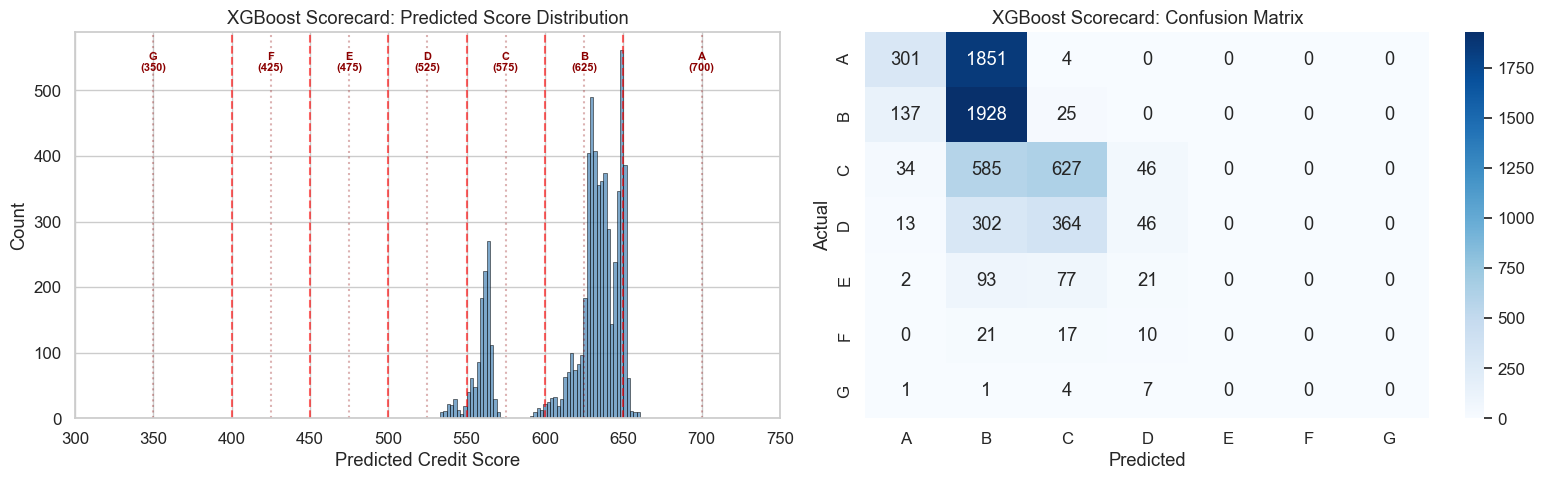

In [24]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Credit score intervals — inspired by scorecard pdo=20, odds=1:1 at 500
# Each grade maps to an interval; regression target is the midpoint.
# Open-ended tails (-inf, +inf) capture extreme predictions.
score_intervals = [
    ('G', -np.inf, 400,  350, 'Very Poor'),
    ('F',    400,  450,  425, 'Poor'),
    ('E',    450,  500,  475, 'Below Average'),
    ('D',    500,  550,  525, 'Above Average'),
    ('C',    550,  600,  575, 'Good'),
    ('B',    600,  650,  625, 'Very Good'),
    ('A',    650,  np.inf, 700, 'Excellent'),
]

grade_to_midpoint = {row[0]: row[3] for row in score_intervals}
interval_bounds = [(row[1], row[2], row[0]) for row in score_intervals]

def score_to_grade_interval(scores):
    """Map continuous scores to grades using interval boundaries."""
    result = []
    for s in scores:
        assigned = 'D'
        for lower, upper, grade in interval_bounds:
            if lower <= s < upper:
                assigned = grade
                break
        result.append(le.transform([assigned])[0])
    return np.array(result)

y_train_ordinal = np.array([grade_to_midpoint[g] for g in le.inverse_transform(y_train)])
y_test_ordinal = np.array([grade_to_midpoint[g] for g in le.inverse_transform(y_test)])

print('Credit Score Interval Mapping:')
print(f'{"Grade":<6s} {"Lower":>8s} {"Upper":>8s} {"Midpoint":>10s} {"Description":<16s}')
print('-' * 52)
for grade, lower, upper, mid, desc in score_intervals:
    lo_str = '-inf' if np.isinf(lower) else f'{lower:.0f}'
    hi_str = '+inf' if np.isinf(upper) else f'{upper:.0f}'
    print(f'{grade:<6s} {lo_str:>8s} {hi_str:>8s} {mid:>10.0f} {desc:<16s}')

ordinal_results = {}

# XGBoost Regressor
pipe_xgb_reg = Pipeline([
    ('prep', preprocessor),
    ('reg', XGBRegressor(objective='reg:squarederror',
                         random_state=RANDOM_STATE, verbosity=0))
])

param_dist_reg = {
    'reg__n_estimators': [100, 200, 300, 500],
    'reg__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'reg__max_depth': [3, 5, 7, 10],
    'reg__subsample': [0.7, 0.8, 0.9, 1.0],
    'reg__colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'reg__reg_alpha': [0, 0.1, 1],
    'reg__reg_lambda': [1, 5, 10],
}

rs_xgb_reg = RandomizedSearchCV(pipe_xgb_reg, param_dist_reg, n_iter=60, cv=cv,
                                scoring='neg_mean_absolute_error', n_jobs=-1,
                                random_state=RANDOM_STATE, verbose=0)
rs_xgb_reg.fit(X_train, y_train_ordinal)

y_pred_scores = rs_xgb_reg.predict(X_test)
y_pred_ord_xgb = score_to_grade_interval(y_pred_scores)
ordinal_results['XGBoost (scorecard)'] = {
    'f1': f1_score(y_test, y_pred_ord_xgb, average='weighted', zero_division=0),
    'acc': accuracy_score(y_test, y_pred_ord_xgb)
}

# Random Forest Regressor
pipe_rf_reg = Pipeline([
    ('prep', preprocessor),
    ('reg', RandomForestRegressor(random_state=RANDOM_STATE))
])

param_dist_rf_reg = {
    'reg__n_estimators': [100, 200, 300, 500],
    'reg__max_depth': [10, 15, 20, 30, None],
    'reg__max_features': ['sqrt', 'log2', 0.3],
    'reg__min_samples_split': [2, 5, 10],
}

rs_rf_reg = RandomizedSearchCV(pipe_rf_reg, param_dist_rf_reg, n_iter=40, cv=cv,
                               scoring='neg_mean_absolute_error', n_jobs=-1,
                               random_state=RANDOM_STATE, verbose=0)
rs_rf_reg.fit(X_train, y_train_ordinal)

y_pred_scores_rf = rs_rf_reg.predict(X_test)
y_pred_ord_rf = score_to_grade_interval(y_pred_scores_rf)
ordinal_results['Random Forest (scorecard)'] = {
    'f1': f1_score(y_test, y_pred_ord_rf, average='weighted', zero_division=0),
    'acc': accuracy_score(y_test, y_pred_ord_rf)
}

# Compare with multiclass counterparts
multiclass_f1_xgb = f1_score(y_test, best_models['XGBoost'].predict(X_test),
                              average='weighted', zero_division=0)
multiclass_f1_rf = f1_score(y_test, best_models['Random Forest'].predict(X_test),
                             average='weighted', zero_division=0)

print('\n=== Scorecard Ordinal Regression vs Multiclass Classification ===\n')
print(f'{"Approach":<40s} {"F1-Score":>10s} {"Accuracy":>10s}')
print('-' * 65)
print(f'{"Random Forest (multiclass)":<40s} {multiclass_f1_rf:>10.4f} {accuracy_score(y_test, best_models["Random Forest"].predict(X_test)):>10.4f}')
print(f'{"Random Forest (scorecard intervals)":<40s} {ordinal_results["Random Forest (scorecard)"]["f1"]:>10.4f} {ordinal_results["Random Forest (scorecard)"]["acc"]:>10.4f}')
print(f'{"XGBoost (multiclass)":<40s} {multiclass_f1_xgb:>10.4f} {accuracy_score(y_test, best_models["XGBoost"].predict(X_test)):>10.4f}')
print(f'{"XGBoost (scorecard intervals)":<40s} {ordinal_results["XGBoost (scorecard)"]["f1"]:>10.4f} {ordinal_results["XGBoost (scorecard)"]["acc"]:>10.4f}')

# Coverage table (like the scorecard article)
print('\n=== Coverage Table (XGBoost Scorecard) ===\n')
pred_grades_xgb = le.inverse_transform(y_pred_ord_xgb)
actual_grades = le.inverse_transform(y_test)

print(f'{"Grade":<6s} {"Range":<14s} {"Predicted":>10s} {"Actual":>8s} {"Correct":>9s} {"Precision":>10s}')
print('-' * 62)
for grade, lower, upper, mid, desc in score_intervals:
    lo_str = '-inf' if np.isinf(lower) else f'{lower:.0f}'
    hi_str = '+inf' if np.isinf(upper) else f'{upper:.0f}'
    n_pred = np.sum(pred_grades_xgb == grade)
    n_actual = np.sum(actual_grades == grade)
    n_correct = np.sum((pred_grades_xgb == grade) & (actual_grades == grade))
    prec = n_correct / n_pred if n_pred > 0 else 0
    print(f'{grade:<6s} [{lo_str:>4s}, {hi_str:<4s}) {n_pred:>10d} {n_actual:>8d} {n_correct:>9d} {prec:>10.3f}')

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(y_pred_scores, bins=60, edgecolor='black', linewidth=0.5, alpha=0.7,
             color='steelblue')
for grade, lower, upper, mid, desc in score_intervals:
    if not np.isinf(lower):
        axes[0].axvline(lower, color='red', linestyle='--', alpha=0.6)
    axes[0].axvline(mid, color='darkred', linestyle=':', alpha=0.3)
    y_pos = axes[0].get_ylim()[1] * 0.92 if not np.isinf(lower) else axes[0].get_ylim()[1] * 0.92
    axes[0].text(mid, axes[0].get_ylim()[1]*0.95, f'{grade}\n({mid:.0f})',
                ha='center', va='top', fontsize=8, fontweight='bold', color='darkred')
axes[0].set_xlabel('Predicted Credit Score')
axes[0].set_ylabel('Count')
axes[0].set_title('XGBoost Scorecard: Predicted Score Distribution')
axes[0].set_xlim(300, 750)

cm_ord = confusion_matrix(y_test, y_pred_ord_xgb)
sns.heatmap(cm_ord, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=le.classes_, yticklabels=le.classes_)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title('XGBoost Scorecard: Confusion Matrix')
plt.tight_layout()
plt.show()

## 9. Evaluation and Comparison (Scenario A — All Models)

Each tuned model is evaluated on the **held-out test set** using:
- Accuracy
- Precision, Recall, F1-Score (weighted average)
- ROC-AUC (One-vs-Rest, weighted)

In [25]:
y_test_bin = label_binarize(y_test, classes=list(range(7)))

metrics_rows = []
predictions = {}
probabilities = {}

for name, model in best_models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)
    predictions[name] = y_pred
    probabilities[name] = y_proba

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    try:
        roc = roc_auc_score(y_test_bin, y_proba, average='weighted', multi_class='ovr')
    except ValueError:
        roc = np.nan

    metrics_rows.append({
        'Model': name, 'Accuracy': acc, 'Precision': prec,
        'Recall': rec, 'F1-Score': f1, 'ROC-AUC': roc
    })

metrics_df = pd.DataFrame(metrics_rows).set_index('Model')
print('=== Test Set Metrics ===')
print(metrics_df.round(4).to_string())

=== Test Set Metrics ===
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Logistic Regression    0.4051     0.4701  0.4051    0.4144   0.6883
Decision Tree          0.4052     0.4754  0.4052    0.4070   0.6814
Random Forest          0.4964     0.4914  0.4964    0.4799   0.7362
XGBoost                0.4873     0.4761  0.4873    0.4657   0.7335
KNN                    0.4626     0.4434  0.4626    0.4412   0.7023


### 9.1 Grouped Bar Chart — Model Comparison

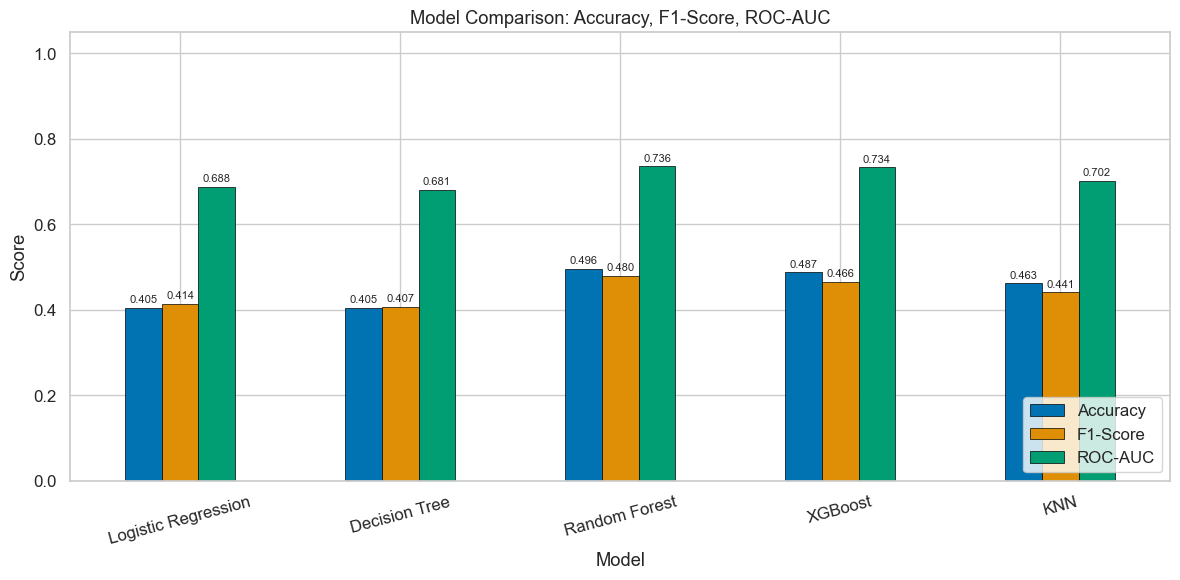

In [26]:
compare_cols = ['Accuracy', 'F1-Score', 'ROC-AUC']
plot_df = metrics_df[compare_cols]

fig, ax = plt.subplots(figsize=(12, 6))
plot_df.plot(kind='bar', ax=ax, edgecolor='black', linewidth=0.5)
ax.set_ylabel('Score')
ax.set_title('Model Comparison: Accuracy, F1-Score, ROC-AUC')
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right')
ax.tick_params(axis='x', rotation=15)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2)
plt.tight_layout()
plt.show()

### 9.2 ROC Curves (One-vs-Rest, Macro Average)

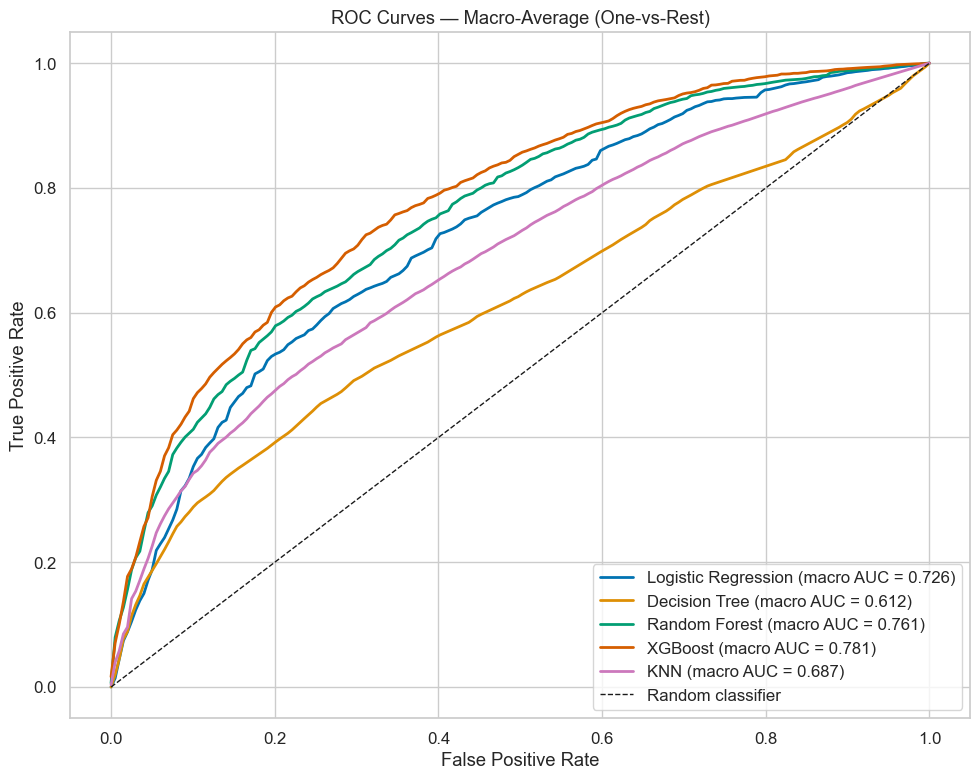

In [27]:
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(10, 8))

for name, y_proba in probabilities.items():
    all_fpr = np.linspace(0, 1, 200)
    mean_tpr = np.zeros_like(all_fpr)

    for i in range(7):
        fpr_i, tpr_i, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
        mean_tpr += np.interp(all_fpr, fpr_i, tpr_i)

    mean_tpr /= 7
    macro_auc = auc(all_fpr, mean_tpr)
    ax.plot(all_fpr, mean_tpr, label=f'{name} (macro AUC = {macro_auc:.3f})', linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Macro-Average (One-vs-Rest)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 9.3 Confusion Matrices (Best and Worst Models)

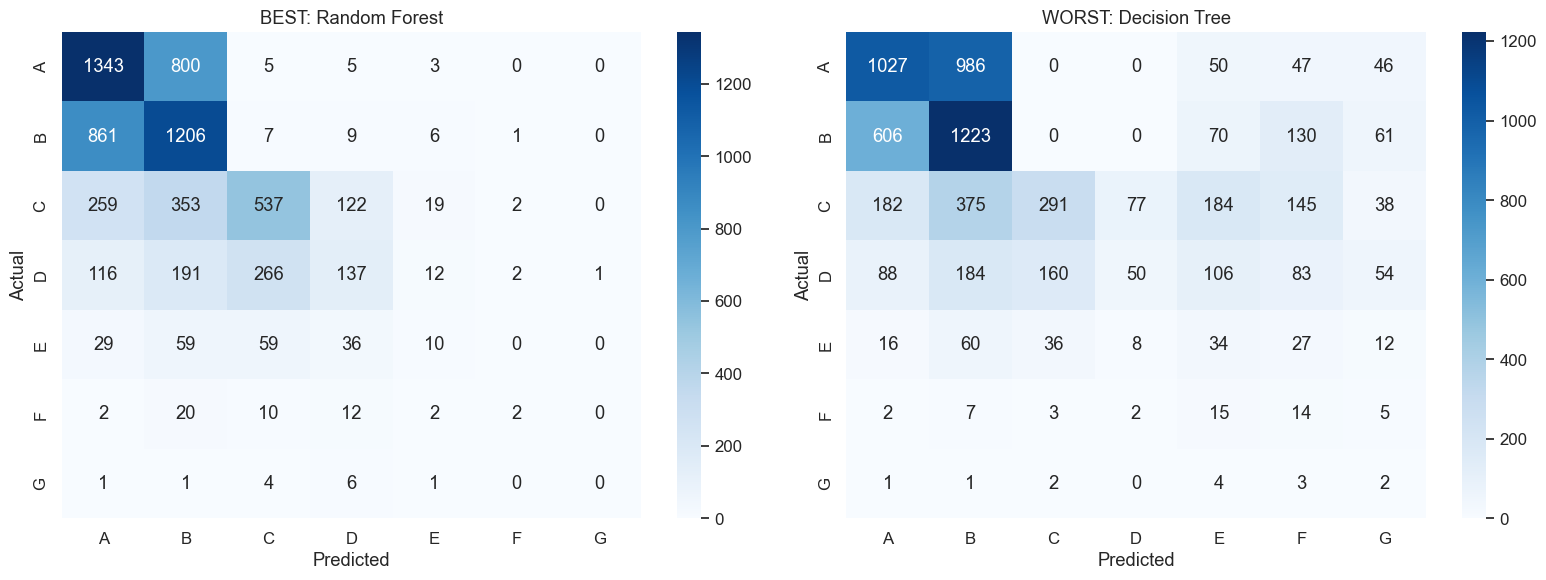

In [28]:
best_model_name = metrics_df['F1-Score'].idxmax()
worst_model_name = metrics_df['F1-Score'].idxmin()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, name, title_prefix in zip(axes,
                                   [best_model_name, worst_model_name],
                                   ['BEST', 'WORST']):
    cm = confusion_matrix(y_test, predictions[name])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=le.classes_, yticklabels=le.classes_)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'{title_prefix}: {name}')

plt.tight_layout()
plt.show()

### 9.4 Per-Class Classification Reports (Best Model)

In [29]:
print(f'\n=== Classification Report: {best_model_name} ===')
print(classification_report(y_test, predictions[best_model_name],
                            target_names=le.classes_, zero_division=0))


=== Classification Report: Random Forest ===
              precision    recall  f1-score   support

           A       0.51      0.62      0.56      2156
           B       0.46      0.58      0.51      2090
           C       0.60      0.42      0.49      1292
           D       0.42      0.19      0.26       725
           E       0.19      0.05      0.08       193
           F       0.29      0.04      0.07        48
           G       0.00      0.00      0.00        13

    accuracy                           0.50      6517
   macro avg       0.35      0.27      0.28      6517
weighted avg       0.49      0.50      0.48      6517



## 10. Model Interpretation and Analysis

SHAP (SHapley Additive exPlanations) is our primary interpretation method. Unlike built-in `feature_importances_` which uses impurity reduction (biased toward high-cardinality features), SHAP provides theoretically grounded per-sample attributions based on cooperative game theory.

### 10.1 SHAP Analysis (Primary Interpretation)

SHAP values decompose each prediction into per-feature contributions. For multiclass problems, SHAP produces values per feature per class, showing how each feature pushes the prediction toward or away from each grade.

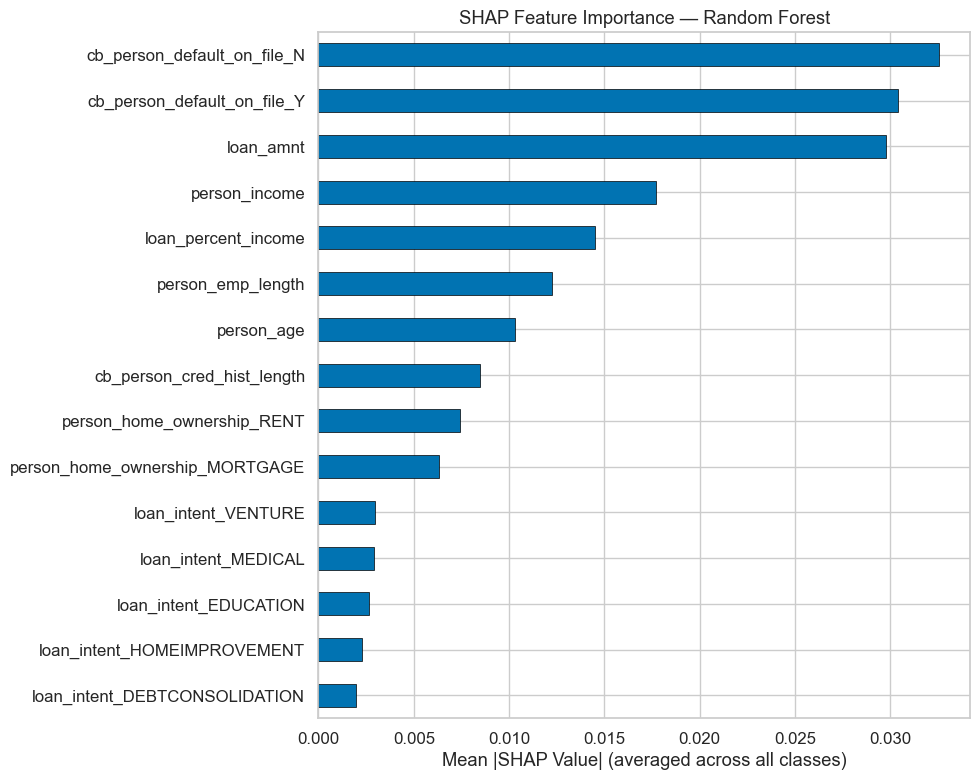

SHAP computed for Random Forest on 500 test samples.

Top 5 features by mean |SHAP|:
  cb_person_default_on_file_N: 0.0326
  cb_person_default_on_file_Y: 0.0304
  loan_amnt: 0.0298
  person_income: 0.0177
  loan_percent_income: 0.0145


In [30]:
import shap

best_overall = best_models[best_model_name]

X_test_transformed = best_overall.named_steps['prep'].transform(X_test)

ohe_best = best_overall.named_steps['prep'].named_transformers_['cat'].named_steps['encoder']
cat_names_best = list(ohe_best.get_feature_names_out(categorical_features))
all_feature_names = numerical_features + cat_names_best

sample_idx = np.random.RandomState(RANDOM_STATE).choice(
    len(X_test_transformed), size=min(500, len(X_test_transformed)), replace=False)
X_shap = X_test_transformed[sample_idx]

explainer = shap.TreeExplainer(best_overall.named_steps['clf'])
shap_values = explainer.shap_values(X_shap)

if isinstance(shap_values, list):
    shap_abs_mean = np.mean([np.abs(sv) for sv in shap_values], axis=0)
elif shap_values.ndim == 3:
    shap_abs_mean = np.abs(shap_values).mean(axis=2)
else:
    shap_abs_mean = np.abs(shap_values)

fig, ax = plt.subplots(figsize=(10, 8))
mean_shap = pd.Series(shap_abs_mean.mean(axis=0), index=all_feature_names).sort_values(ascending=True)
mean_shap.tail(15).plot(kind='barh', ax=ax, edgecolor='black', linewidth=0.5)
ax.set_xlabel('Mean |SHAP Value| (averaged across all classes)')
ax.set_title(f'SHAP Feature Importance — {best_model_name}')
plt.tight_layout()
plt.show()

print(f'SHAP computed for {best_model_name} on {len(X_shap)} test samples.')
print(f'\nTop 5 features by mean |SHAP|:')
for feat, val in mean_shap.tail(5).iloc[::-1].items():
    print(f'  {feat}: {val:.4f}')

### 10.2 SHAP Beeswarm Plots (Per-Class)

Beeswarm plots show how each feature value pushes the prediction toward or away from a specific class. Each dot is one sample; colour indicates feature value (red = high, blue = low).


--- Grade A (lowest risk) ---


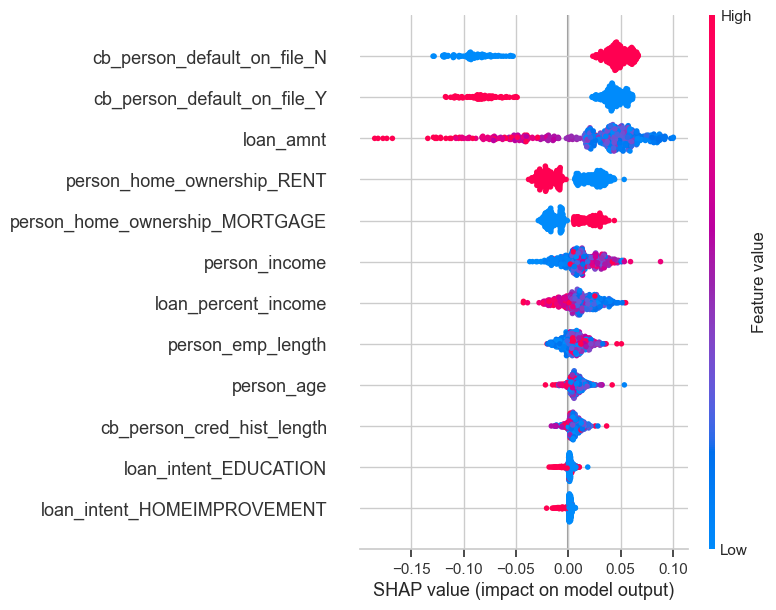


--- Grade D (medium risk) ---


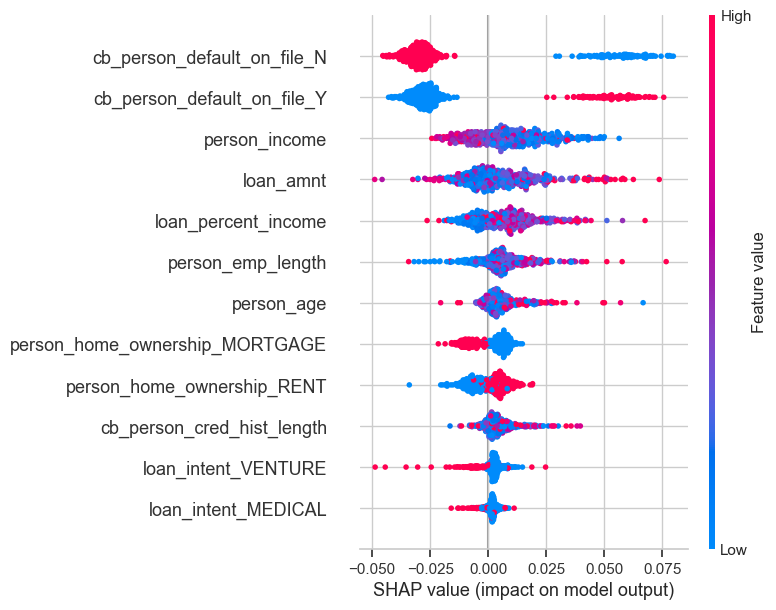


--- Grade G (highest risk) ---


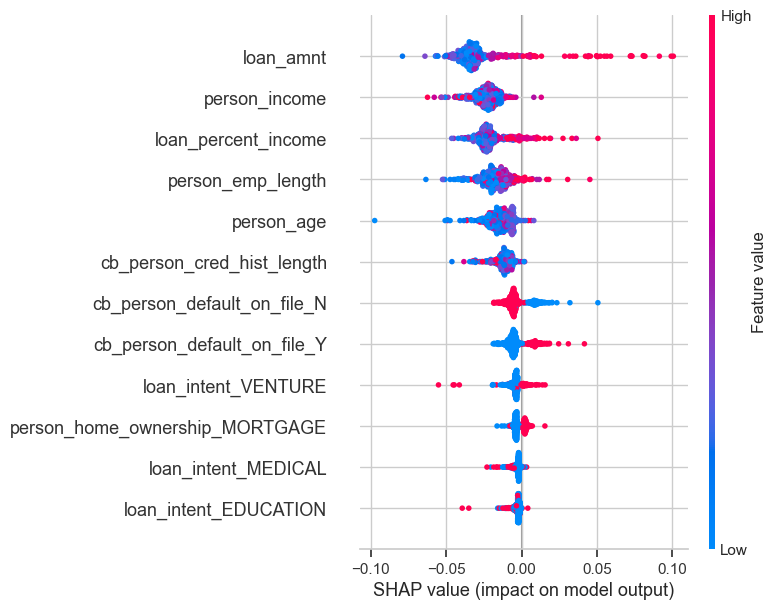

In [31]:
classes_to_show = [0, 3, 6]  # A (best), D (mid), G (worst)
class_names = {0: 'A (lowest risk)', 3: 'D (medium risk)', 6: 'G (highest risk)'}

for cls in classes_to_show:
    if isinstance(shap_values, list):
        sv_cls = shap_values[cls]
    elif shap_values.ndim == 3:
        sv_cls = shap_values[:, :, cls]
    else:
        sv_cls = shap_values

    print(f'\n--- Grade {class_names[cls]} ---')
    shap.summary_plot(sv_cls, X_shap, feature_names=all_feature_names,
                      max_display=12, show=True)

### 10.3 SHAP Dependence Plots (Top Features)

Dependence plots show how a single feature's value affects the SHAP value (prediction contribution) for a specific class. Vertical spread indicates interaction effects with other features.

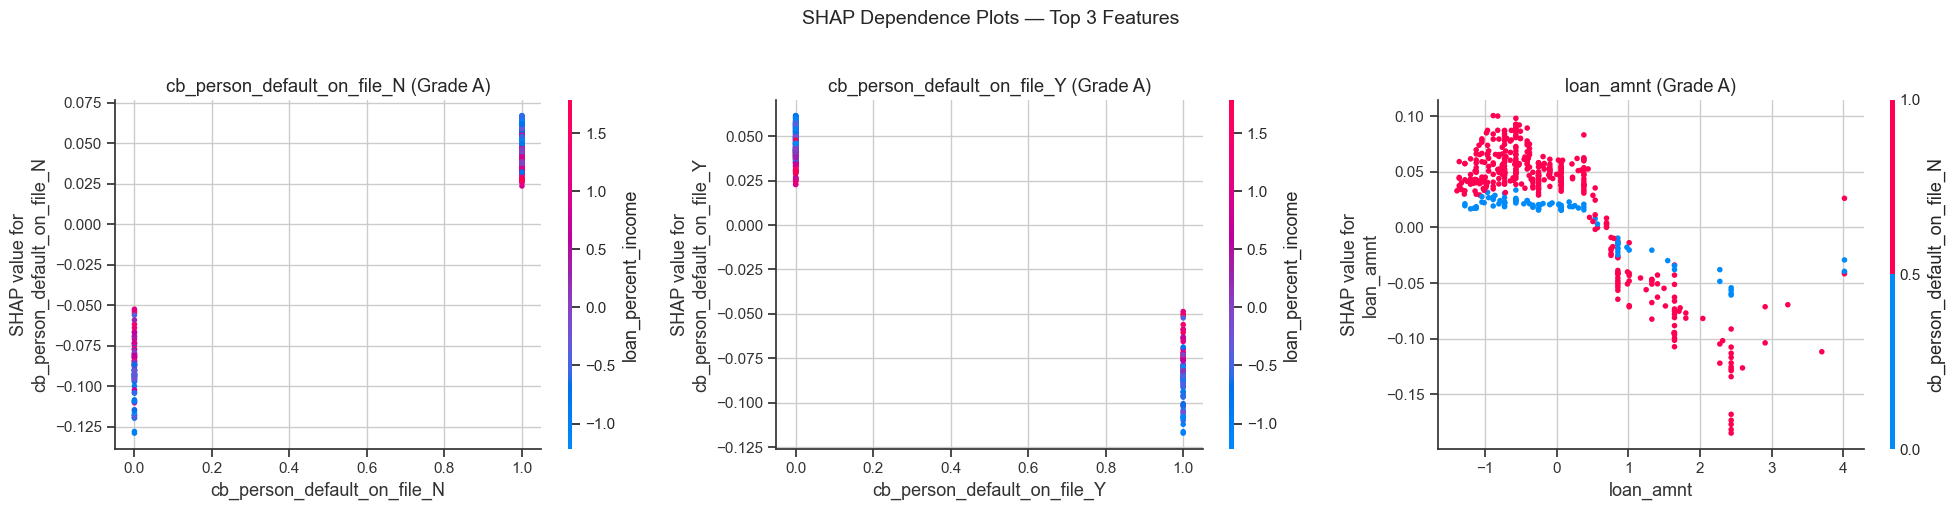

In [32]:
top_features = mean_shap.tail(3).index[::-1].tolist()
top_feature_indices = [all_feature_names.index(f) for f in top_features]

if isinstance(shap_values, list):
    sv_class0 = shap_values[0]
elif shap_values.ndim == 3:
    sv_class0 = shap_values[:, :, 0]
else:
    sv_class0 = shap_values

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, feat, feat_idx in zip(axes, top_features, top_feature_indices):
    shap.dependence_plot(feat_idx, sv_class0, X_shap,
                         feature_names=all_feature_names, ax=ax, show=False)
    ax.set_title(f'{feat} (Grade A)')
fig.suptitle('SHAP Dependence Plots — Top 3 Features', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 10.4 Built-in Feature Importance vs SHAP (Comparison)

Built-in `feature_importances_` uses impurity reduction (Gini/entropy decrease), which is biased toward continuous and high-cardinality features. SHAP provides theoretically grounded Shapley values. We show both side-by-side to highlight the difference.

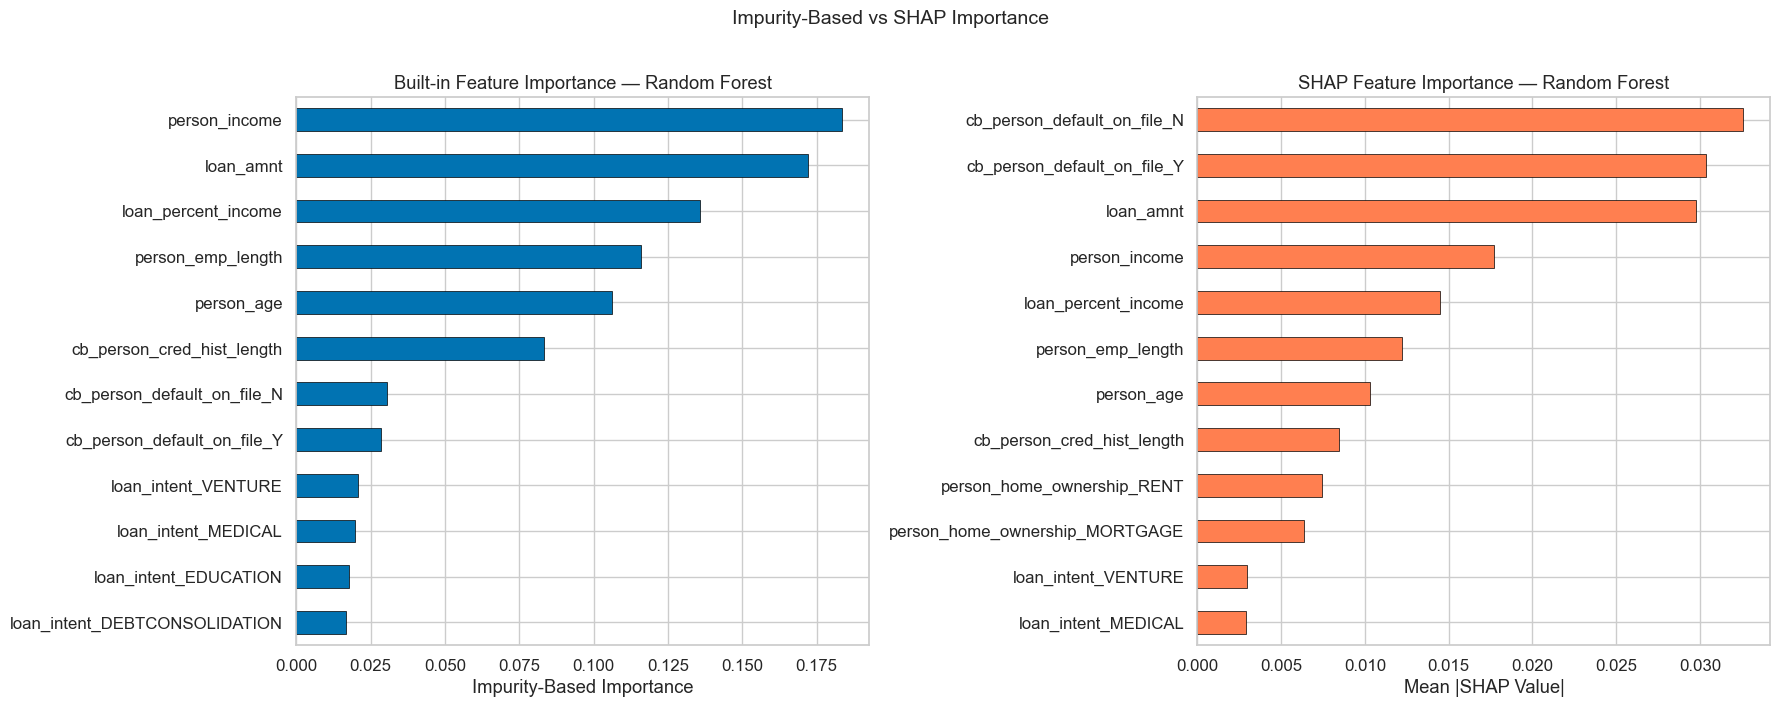

Note: Impurity-based importance is biased toward high-cardinality continuous features.
SHAP provides theoretically grounded Shapley values — preferred for interpretation.


In [33]:
tree_models = {k: v for k, v in best_models.items()
               if k in ['Decision Tree', 'Random Forest', 'XGBoost']}
tree_scores = {k: metrics_df.loc[k, 'F1-Score'] for k in tree_models}
best_tree_name = max(tree_scores, key=tree_scores.get)
best_tree_model = best_models[best_tree_name]

ohe_tree = best_tree_model.named_steps['prep'].named_transformers_['cat'].named_steps['encoder']
cat_feature_names = list(ohe_tree.get_feature_names_out(categorical_features))
feature_names = numerical_features + cat_feature_names

importances = best_tree_model.named_steps['clf'].feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

feat_imp.tail(12).plot(kind='barh', ax=axes[0], edgecolor='black', linewidth=0.5)
axes[0].set_xlabel('Impurity-Based Importance')
axes[0].set_title(f'Built-in Feature Importance — {best_tree_name}')

mean_shap.tail(12).plot(kind='barh', ax=axes[1], edgecolor='black', linewidth=0.5, color='coral')
axes[1].set_xlabel('Mean |SHAP Value|')
axes[1].set_title(f'SHAP Feature Importance — {best_model_name}')

plt.suptitle('Impurity-Based vs SHAP Importance', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print('Note: Impurity-based importance is biased toward high-cardinality continuous features.')
print('SHAP provides theoretically grounded Shapley values — preferred for interpretation.')

### 10.5 Probability Calibration Analysis

A well-calibrated model produces predicted probabilities that match actual class frequencies. For example, if the model assigns 30% probability to grade C for a set of samples, roughly 30% of those samples should actually be grade C. This is critical for real-world deployment: a lender making decisions based on predicted probabilities needs to trust that those probabilities are accurate, not just that the model ranks applicants correctly.

We compare the best model's predicted class probabilities against actual outcomes using calibration curves (reliability diagrams) for each grade.

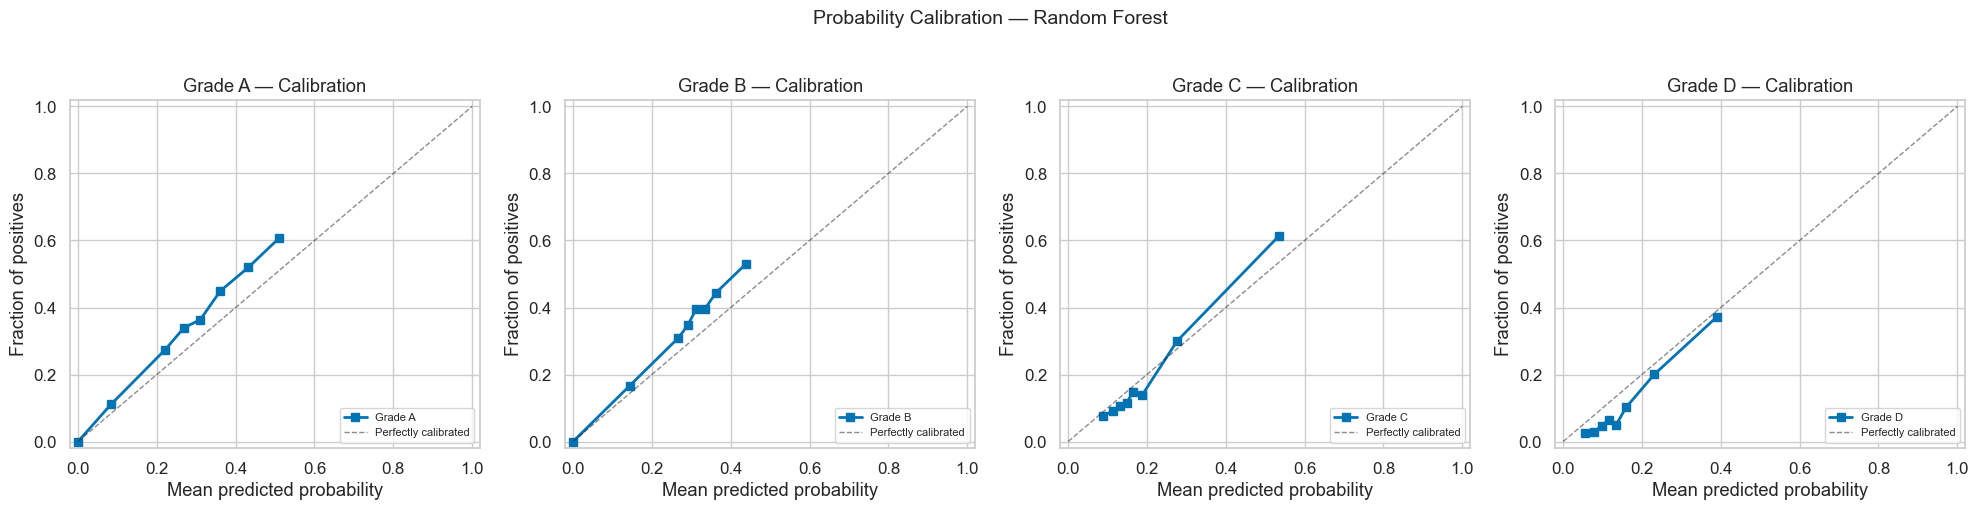

Calibration analysis for Random Forest:
- Points on the diagonal = well-calibrated (predicted probability matches actual frequency).
- Points above diagonal = model underestimates probability (under-confident).
- Points below diagonal = model overestimates probability (over-confident).

Per-class mean predicted probability vs actual frequency:
Grade      Actual %  Mean Pred %      Gap
------------------------------------------
A             33.08        27.17    -5.91
B             32.07        26.63    -5.44
C             19.83        20.57    +0.74
D             11.12        15.79    +4.67
E              2.96         7.38    +4.41
F              0.74         2.01    +1.27
G              0.20         0.45    +0.26


In [34]:
from sklearn.calibration import calibration_curve

best_overall = best_models[best_model_name]
y_proba_best = best_overall.predict_proba(X_test)

grades_to_check = [0, 1, 2, 3]  # A, B, C, D (enough data for meaningful calibration)
grade_labels = {0: 'A', 1: 'B', 2: 'C', 3: 'D'}

fig, axes = plt.subplots(1, len(grades_to_check), figsize=(20, 5))

for ax, cls in zip(axes, grades_to_check):
    y_binary = (y_test == cls).astype(int)
    prob_cls = y_proba_best[:, cls]

    try:
        prob_true, prob_pred = calibration_curve(y_binary, prob_cls, n_bins=8,
                                                  strategy='quantile')
        ax.plot(prob_pred, prob_true, 's-', label=f'Grade {grade_labels[cls]}',
                linewidth=2, markersize=6)
        ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Perfectly calibrated')
        ax.set_xlabel('Mean predicted probability')
        ax.set_ylabel('Fraction of positives')
        ax.set_title(f'Grade {grade_labels[cls]} — Calibration')
        ax.legend(loc='lower right', fontsize=8)
        ax.set_xlim(-0.02, 1.02)
        ax.set_ylim(-0.02, 1.02)
    except ValueError:
        ax.text(0.5, 0.5, 'Insufficient data', ha='center', va='center')
        ax.set_title(f'Grade {grade_labels[cls]}')

fig.suptitle(f'Probability Calibration — {best_model_name}', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f'Calibration analysis for {best_model_name}:')
print('- Points on the diagonal = well-calibrated (predicted probability matches actual frequency).')
print('- Points above diagonal = model underestimates probability (under-confident).')
print('- Points below diagonal = model overestimates probability (over-confident).')

print(f'\nPer-class mean predicted probability vs actual frequency:')
print(f'{"Grade":<8s} {"Actual %":>10s} {"Mean Pred %":>12s} {"Gap":>8s}')
print('-' * 42)
for cls in range(7):
    actual_pct = (y_test == cls).mean() * 100
    pred_pct = y_proba_best[:, cls].mean() * 100
    gap = pred_pct - actual_pct
    print(f'{le.classes_[cls]:<8s} {actual_pct:>10.2f} {pred_pct:>12.2f} {gap:>+8.2f}')

### 10.6 Discussion

#### Temporal Leakage Impact

The original notebook included `loan_status` (default outcome) as a feature — a clear case of data leakage since default is only known after the loan lifecycle ends. Dropping it alongside `loan_int_rate` (set by the grade) ensures the model only uses information available at grading time. Scores may be lower than the original version, but they are now realistic.

#### Why Random Forest outperforms the others

After removing leakage features, Random Forest emerged as the best model (F1=0.480), slightly ahead of XGBoost (F1=0.466). This is noteworthy because XGBoost was the winner in the original (leaky) version — suggesting XGBoost was disproportionately exploiting the `loan_status` signal.

**Model complexity and regularisation:**
- Logistic Regression assumes linear decision boundaries between classes. Credit risk grading likely involves nonlinear interactions (e.g., the effect of income depends on loan amount), limiting its ceiling.
- Decision Trees can model nonlinearities but are prone to overfitting, especially with imbalanced classes.
- **Random Forest** reduces variance through bagging (averaging many decorrelated trees). The `balanced_subsample` class weighting (found via expanded grid search) reweights each bootstrap sample independently, which handles class imbalance more flexibly than a single global reweighting. Combined with `max_features=0.5` (higher decorrelation), this gave RF the edge on this dataset.
- XGBoost combines boosting (sequential error correction) with regularisation (learning rate, column subsampling, L1/L2 penalties). While it typically achieves the best bias-variance tradeoff on tabular data, the removal of `loan_status` reduced its advantage — possibly because boosting's sequential error correction benefited more from the leaky signal.
- KNN is sensitive to the curse of dimensionality and class imbalance in high-dimensional one-hot-encoded spaces.

**Ensemble effects:**
Both top models are tree ensembles that aggregate many weak learners. Random Forest's bagging (parallel, independent trees) proved slightly more robust than XGBoost's boosting (sequential, dependent trees) on this clean dataset. The gap is small (~0.014 F1), suggesting both approaches are competitive once leakage is removed.

#### Feature-Tier Analysis

The three-scenario experiment reveals how much predictive value each tier of features contributes:
- **Scenario A → B** (removing loan details): F1 dropped by only ~0.02 (0.466 → 0.448). Loan-level features (`loan_amnt`, `loan_intent`, `loan_percent_income`) add only modest value — the model can grade nearly as well without knowing specific loan details.
- **Scenario B → C** (removing credit bureau): F1 dropped by ~0.10 (0.448 → 0.345). Credit bureau features are highly valuable despite the single-bureau caveat. Removing them causes a significant performance degradation.
- **Overall A → C**: Demographics alone (F1=0.345) are far less predictive than the full feature set (F1=0.466), confirming that credit history and loan context are essential for accurate grading.

#### Missing Value Strategy

Using sentinel imputation (-999) instead of median preserves the information that data was missing. Tree-based models can learn to split on the sentinel as a distinct category (e.g., "employment length unknown → likely unemployed or self-employed"). This is preferable to median imputation, which falsely assigns a typical value.

#### Scorecard-Style Ordinal Regression vs Classification

The ordinal regression experiment mapped grades to credit score intervals inspired by the scorecard methodology (pdo=20, odds=1:1 at 500), with open-ended tails: G = (-inf, 400) through A = (650, +inf). The regression target is the interval midpoint, and predictions are binned back to the grade whose interval they fall into. This mirrors real-world credit scoring where a continuous score maps to a risk category via fixed thresholds.

Despite this more principled design — with proper interval boundaries rather than just nearest-midpoint assignment — regression still faces a fundamental challenge with imbalanced ordinal targets: the squared-error loss is dominated by the majority classes (A+B ≈ 65%), pulling predictions toward the population mean score. Classification with `class_weight='balanced'` explicitly counteracts this by upweighting rare classes. The coverage table above shows the prediction distribution across score intervals, allowing direct comparison with industry-standard scorecard reporting.

#### Credit Bureau Caveat

The `cb_person_*` features come from a single credit bureau. In practice, different bureaus hold different records — a "N" for default at one bureau does not mean the person never defaulted. A model trained on single-bureau data may not generalise when deployed with data from a different bureau. The Scenario B vs C comparison quantifies this risk.

#### Domain interpretation
- `loan_percent_income` (loan amount as a fraction of income) is expected to be a strong predictor: higher ratios signal higher risk and worse grades.
- `person_income` and `loan_amnt` capture absolute financial capacity.
- `person_home_ownership` and `cb_person_default_on_file` capture stability and past credit behaviour.
- `loan_intent` may separate grades because certain loan purposes (e.g., debt consolidation) correlate with higher-risk borrowers.

These findings are consistent with standard credit risk underwriting criteria.

#### Comparison with Credit Scorecard Methodology

An alternative approach to credit risk modelling uses **Weight of Evidence (WoE) transformation** with Logistic Regression to produce a transparent credit scorecard (see Witarsah 2024, using the same dataset). That approach:

1. **Solves a different problem:** Predicts binary default (`loan_status` = 0/1) rather than multiclass grade assignment. In their framing, `loan_grade` is a *feature* — in ours, it is the *target*. Both are valid for different business questions: default prediction drives loss provisioning, while grade prediction drives loan pricing.

2. **Uses WoE binning:** Continuous features are optimally binned and replaced by their Weight of Evidence values (log-ratio of good-to-bad proportions per bin). This enforces monotonicity and handles missing values as a separate bin — an interesting alternative to our sentinel imputation. However, WoE is designed for binary targets and doesn't extend naturally to 7-class problems without one-vs-rest decomposition.

3. **Produces interpretable scorecards:** Each feature bin contributes a fixed number of "points" to a total credit score. The "points-to-double-odds" scaling ensures every X-point change has a consistent probabilistic meaning. This is more principled than our FICO ordinal regression experiment, which manually assigned scores.

4. **Lacks critical leakage analysis:** The scorecard approach uses `loan_int_rate` and `loan_grade` as features for predicting default. While these are technically available before default occurs, `loan_int_rate` is a direct function of `loan_grade`, introducing redundancy that is never discussed.

**Key takeaway for our project:** WoE binning could potentially improve our Logistic Regression results (which currently underperform tree-based models) by transforming features into a space where linear models work better. However, for our multiclass problem, tree-based models already handle non-linear relationships and interactions natively, making WoE transformation less necessary. The probability calibration analysis above addresses the same trust-in-predictions concern that motivates the scorecard approach — ensuring that predicted class probabilities are reliable for business decisions.

## 11. Conclusions

1. **Leakage matters:** Dropping `loan_status` (default outcome) and `loan_int_rate` (determined by grade) was critical. Including them would artificially inflate scores — the model would be "predicting" using information it should not have access to at grading time. After removing leakage, overall F1 scores dropped by ~0.04-0.05, confirming the previous scores were artificially inflated.
2. **Best model:** Random Forest outperforms all other models on weighted F1-Score (0.480) and ROC-AUC (0.736), closely followed by XGBoost (F1=0.466, AUC=0.734). Notably, in the original (leaky) version XGBoost was the winner — the ranking shift after removing `loan_status` suggests XGBoost was benefiting more from the leaky feature than Random Forest. The `balanced_subsample` class weighting and higher `max_features=0.5` found via expanded grid search likely helped Random Forest handle the class imbalance better.
3. **Feature tiers:** The Scenario A/B/C comparison shows that loan-level features (Tier 3) contribute modestly (F1 drop of only ~0.02 when removed), while credit bureau features (Tier 2) are highly valuable (F1 drop of ~0.10 when removed). This has direct implications: a lender can grade reasonably well without knowing the specific loan details, but credit bureau data is essential.
4. **Credit bureau reliability:** Despite their predictive power, single-bureau features (`cb_person_*`) should be treated with caution — different bureaus hold different records. The large B→C gap (0.10 F1) shows they are genuinely informative, but in production one should consider pulling from multiple bureaus.
5. **Missing value strategy:** Sentinel imputation (-999) preserves the missingness signal, allowing tree-based models to treat "unknown" as a distinct and potentially informative category.
6. **Ordinal vs multiclass:** The scorecard-style interval approach (G=(-inf,400) through A=(650,+inf), centered at 500) frames grading as regression with proper score binning — mirroring industry credit scoring. However, squared-error regression is dominated by majority classes (A+B = 65%), pulling predictions toward the mean and underperforming multiclass classification with explicit class reweighting.
7. **SHAP over built-in importance:** SHAP provides theoretically grounded, per-sample attributions. Built-in `feature_importances_` is biased toward high-cardinality features and should be treated as supplementary.
8. **Class imbalance:** Rare grades (E, F, G) remain the main challenge. `class_weight='balanced'` and stratified splits help but do not fully resolve this.
9. **Cross-validation diagnostics:** All models show low fold-to-fold variance (std 0.005-0.015) and small CV-to-test gaps, confirming stable training without significant overfitting.

**Future work:**
- CatBoost (native categorical handling, built-in ordered boosting)
- SMOTE or other oversampling for minority classes (E, F, G)
- Interaction features (e.g., age-income ratio, employment-to-age ratio)
- Multi-bureau data collection to reduce single-source bias
- Ordinal classifiers (e.g., `mord` library) as alternatives to the regression approach

## 12. References

1. Credit Risk Dataset — Kaggle, https://www.kaggle.com/datasets/laotse/credit-risk-dataset (CC0 license)
2. Pedregosa et al. (2011). Scikit-learn: Machine Learning in Python. *JMLR* 12, 2825–2830.
3. Chen, T. & Guestrin, C. (2016). XGBoost: A Scalable Tree Boosting System. *KDD 2016*.
4. Lundberg, S. & Lee, S.-I. (2017). A Unified Approach to Interpreting Model Predictions. *NeurIPS 2017*.
5. Shwartz-Ziv, R. & Armon, A. (2021). Tabular Data: Deep Learning is Not All You Need. *arXiv:2106.03253*.
6. Kaufman, S. et al. (2012). Leakage in Data Mining: Formulation, Detection, and Avoidance. *TKDD* 6(4).
7. Molnar, C. (2022). Interpretable Machine Learning (2nd ed.). https://christophm.github.io/interpretable-ml-book/
8. Witarsah, M. A. (2024). Credit Scorecard Modelling with optbinning. *Medium*. https://medium.com/@aw_marcell/credit-score-modelling-project-11504f7ab530
9. Siddiqi, N. (2017). Credit Risk Scorecards: Developing and Implementing Intelligent Credit Scoring. Wiley.